In [1]:
#Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re, ast
import seaborn as sns
import geopandas as gpd
import geodatasets as gdsets
from geodatasets import get_path
import warnings, os
import spacy, nltk, textblob
import dask.dataframe as dd

In [ ]:
prof = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviantArt_snwBall_fin/deviants_profileSnwball_fin1.csv.gz")

In [5]:
prof.nunique()

Unnamed: 0.1         133133
user                 137766
profil_url           137765
tags                  16002
country                 408
level                     3
specialty                 9
user_deviations        2893
user_favourites       15905
user_comments         14366
profile_pageviews     50346
profile_comments       6673
Unnamed: 0            77510
tag_line              57258
user_is_artist            2
website               26106
dtype: int64

In [6]:
gall = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviants_gallData_4_5_6/uniqueDev_gall_SnwBall03_6.2.csv.gz")
gall.nunique()

Deviation_id              13168262
Deviation_url             13168262
Deviation_title            9587228
Author_id                    56121
Author_name                  56121
Author_type                      6
Published_on              12877304
Deviation_source          12770075
Deviation_height             12245
Deviation_width              10237
Deviation_transparency           2
Comments                      2350
is_Mature                        2
is_Downloadable                  2
Favourites                   12241
dtype: int64

In [21]:
wtchrs = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviantArt_snwBall_fin/deviants_wtchrsSnwball_fin1.csv.gz")

/tmp/ipykernel_1274976/3992781955.py:1: DtypeWarning: Columns (12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  wtchrs = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviantArt_snwBall_fin/deviants_wtchrsSnwball_fin1.csv.gz")


In [23]:
# Source - https://stackoverflow.com/a
# Posted by Rahul Mandre, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-15, License - CC BY-SA 4.0

print(wtchrs.apply(lambda col: col.unique()))

Unnamed: 0       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
Watchers name    [TerrormisuTiaramisu, petdan64, gusjohnbro44, ...
user_icon        [https://a.deviantart.net/avatars/t/e/terrormi...
type             [regular, premium, banned, senior, admin, volu...
is_watching                                                [False]
last_visit       [2025-03-06T11:55:18-0800, 2025-03-07T04:32:43...
activity                                             [True, False]
collections                                          [True, False]
critiques                                                  [False]
deviations                                           [True, False]
forum_threads                                        [True, False]
friend                                               [True, False]
journals                                        [True, False, nan]
scraps                                          [False, True, nan]
Deviant          [acebeny, Deviant, Theli-at, classina, WayneB

None


In [24]:
frnds = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviantArt_snwBall_fin/deviants_friendsSnwball_fin.csv.gz")

/tmp/ipykernel_1274976/3482456485.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  frnds = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviantArt_snwBall_fin/deviants_friendsSnwball_fin.csv.gz")


In [25]:
frnds.head()

,Unnamed: 0,Friends name,user_icon,type,is_watching,last_visit,friends,deviations,journals,forum_threads,critiques,scraps,activity,collections,Deviant,watches_you
0,0,msRainie,https://a.deviantart.net/avatars/m/s/msrainie....,regular,False,NaN,True,True,True,True,False,False,True,True,acebeny,NaN
1,1,nudagimo,https://a.deviantart.net/avatars/n/u/nudagimo....,regular,False,NaN,True,True,True,True,False,False,True,True,acebeny,NaN
2,2,SuzieKatz,https://a.deviantart.net/avatars/s/u/suziekatz...,premium,False,2022-10-24T04:19:55-0700,True,True,True,True,False,False,True,True,acebeny,NaN
3,3,21st-Century-Artist,https://a.deviantart.net/avatars/2/1/21st-cent...,group,False,2014-02-16T03:31:22-0800,False,True,True,True,False,False,True,True,Theli-at,NaN
4,4,Adellanuki,https://a.deviantart.net/avatars/a/d/adellanuk...,premium,False,NaN,True,True,True,True,False,False,True,True,Theli-at,NaN


In [11]:
meta = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviantArt_snwBall_fin/deviants_metaDataSnwBall/uniqueDev_metaData_SnwBall_02.csv.gz")

In [12]:
meta.nunique()

Devtn_Id             3831690
Devtn_Title          2930311
Devtn_Descp          2632837
Author_Id              13594
Author_Name            13594
Author_Icon            13315
Author_Type                7
License                    7
Allows_Comments            2
Is_Favourited              1
Is_Mature                  2
Can_post_comments          1
Tags_Info            1033061
tag_name             1033061
Sponsered                129
Sponser                  129
dtype: int64

In [13]:
meta.head()

,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,Author_Icon,Author_Type,License,Allows_Comments,Is_Favourited,Is_Mature,Can_post_comments,Tags_Info,tag_name,Sponsered,Sponser
0,74D26AE5-C304-60CE-F7BD-E9FEC1B86334,White spring Angel,Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'angel', 'sponsored': False, 'sp...","['angel', 'ceramic', 'sculpture', 'art']","[False, False, False, False]","['', '', '', '']"
1,70E67FA4-3DDD-AE0E-AF61-C4A5D532771D,Little White Severong,Hand made porcelain miniature (5 cm).<br /><br...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,[],[],[],[]
2,56BDA73F-224F-A338-233C-EDA6E4A6254D,Pink-Turquoise Unicorn (Soap Dish - Wall picture),Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'ceramic', 'sponsored': False, '...","['ceramic', 'ceramics', 'clay', 'craft', 'gift...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '']"
3,1A2E67EB-E8C1-1798-886D-D2041B464154,Purple-lavender Fox (Soap Dish - Wall picture),Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'ceramic', 'sponsored': False, '...","['ceramic', 'ceramics', 'clay', 'craft', 'fox'...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '']"
4,8B3C0B89-6E36-1C05-6A8C-BF25167D20E7,Turquoise Jellyfish - Soap Dish - Wall,Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'ceramic', 'sponsored': False, '...","['ceramic', 'ceramics', 'clay', 'craft', 'dish...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '..."


In [31]:
from bs4 import BeautifulSoup
import re
import string

def clean_text_column(df, column_name):
    """
    Cleans a DataFrame column containing text data with HTML and links.

    Removes HTML tags, extracts text from links, and keeps only
    alphanumeric characters and spaces, then normalizes whitespace.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the text column to clean.

    Returns:
        pd.Series: A Pandas Series with the cleaned text data.
    """

    cleaned_series = df[column_name].apply(lambda text: clean_single_text(text))

    return cleaned_series

def clean_single_text(text):
    """
    Cleans a single string containing text data with HTML and links.

    Removes HTML tags, extracts text from links, and keeps only
    alphanumeric characters and spaces, then normalizes whitespace.

    Args:
        text (str): The input text string.

    Returns:
        str: The cleaned text string.
    """
    if pd.isna(text):
        return "" # Handle NaN values

    # 1. Remove HTML tags and get text content
    soup = BeautifulSoup(text, 'html.parser')
    text_without_html = soup.get_text()

    # 2. Remove any remaining links (they might appear as bare URLs after soup)
    # This regex matches URLs starting with http, https, or www
    text_without_links = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text_without_html)


    # 3. Keep only alphanumeric characters and spaces
    # This regex keeps letters (a-z, A-Z), numbers (0-9), and spaces.
    # It effectively removes punctuation, symbols, and newline characters.
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', text_without_links)

    # 4. Normalize whitespace (replace multiple spaces with single space and strip)
    cleaned_text = re.sub('\s+', ' ', cleaned_text).strip()

    # 5. Optionally convert to lowercase
    cleaned_text = cleaned_text.lower()

    return cleaned_text


In [32]:
meta["clean_tag_names"] = meta["tag_name"].apply(lambda x: ast.literal_eval(x))
meta["clean_devtn_descp"] = meta["Devtn_Descp"].apply(lambda row: clean_single_text(row))


/tmp/ipykernel_615512/1074588601.py:41: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, 'html.parser')
/tmp/ipykernel_615512/1074588601.py:41: MarkupResemblesLocatorWarning: The input looks more like a URL than markup. You may want to use an HTTP client like requests to get the document behind the URL, and feed that document to Beautiful Soup.
  soup = BeautifulSoup(text, 'html.parser')


In [8]:
meta.clean_devtn_descp.tail()

483208    my participation for roleplaying games advent ...
483209    little watercolor painting featuring my pet ca...
483210    little birthday gift for saigola featuring the...
483211    my part for halloween themed mass trade featur...
483212    gift art for friend featuring their character ...
Name: clean_devtn_descp, dtype: object

In [33]:
key_terms = [
    'ai', 'aiart', 'artificalintelligence', 'Midjourney',
    'StableDiffusion', 'ImageFX', 'ShutterstockAIImageGenerator',
    'AdobeFirefly', 'DallE3', 'MetaAI', 'Flux', 'MicrosoftCopilot',
    'GoogleGemini', 'Grok', 'GettyImagesAIGenerator', 'GenerativeAIbyiStock' 'LLM', 'ChatGPT', 'Gemini', 
    'DeepSeek', 'generative models', 'LargeLanguageModels', 'genai', 'LanguageModels', 'GPT', 'OpenAI'
]

# --- Strategy to match whole words or specific partial words carefully ---
# We want to match:
# 1. The original terms as whole words (\bterm\b)
# 2. Specific important sub-terms as whole words (\bsubterm\b)
# 3. Potentially specific sub-terms *within* words if they are common combinations (less recommended for simplicity)

# Let's refine the list of terms to search for:
# Start with the original key terms
refined_terms = set(key_terms)

# Add specific important sub-terms that should be matched as whole words
refined_terms.add('Shutterstock')
refined_terms.add('GettyImages')
refined_terms.add('AdobeFirefly')
#refined_terms.add('Google')
#refined_terms.add('Microsoft')
refined_terms.add('Gemini') # Specific sub-term from GoogleGemini
refined_terms.add('Copilot') # Specific sub-term from MicrosoftCopilot
refined_terms.add('Midjourney') # Ensure this is explicitly a whole word match
refined_terms.add('StableDiffusion') # Ensure this is explicitly a whole word match
#refined_terms.add('Firefly') # Specific sub-term from AdobeFirefly
refined_terms.add('DallE3') # Ensure this is explicitly a whole word match
refined_terms.add('LanguageModels') # Specific sub-term from AdobeFirefly
#refined_terms.add('LargeLanguage') # Specific sub-term from AdobeFirefly


# Create the new pattern using the collected terms.
# Each term will be matched as a whole word using \b boundaries.
# Escape special regex characters and join with '|'.
escaped_terms_for_whole_word_match = [r'\b' + re.escape(term) + r'\b' for term in refined_terms]

# Add a specific rule for 'AI' or 'Ai' or 'aI' or 'ai' that should be a whole word match
# This is important to avoid matching "available" but still catch "AI" or "ai".
# We add it separately because the simple \b[word]\b structure might be too strict for 'AI'
# depending on surrounding characters like punctuation.
# A robust way to match 'AI' as a distinct unit (word-like):
# Look for \bAI\b or potentially AI surrounded by non-word characters or start/end of string
ai_word_pattern = r'(?:\bAI\b|\bai\b)' # Non-capturing group for clarity

# Combine the patterns: whole word matches for refined terms OR the specific AI word pattern
all_patterns = escaped_terms_for_whole_word_match + [ai_word_pattern]

# Join all patterns with '|' for OR condition
search_pattern_str = '|'.join(all_patterns)

# Compile the regex for efficiency, and make it case-insensitive
search_pattern = re.compile(search_pattern_str, re.IGNORECASE)

def check_for_ai_terms_whole_word(row):
    """
    Checks if any term from the search pattern (primarily whole words)
    exists in either the word list column or the text string column for a given row.

    Args:
        row (pd.Series): A single row from the DataFrame.

    Returns:
        bool: True if a matching term is found in either column, False otherwise.
    """
    word_list = row['clean_tag_names']
    text_string = row['clean_devtn_descp']


    # Check the word list column
    if isinstance(word_list, list): # Ensure it's a list
        for word in word_list:
            if isinstance(word, str) and search_pattern.search(word):
                return True

    # Check the text string column
    # Apply the search pattern to the entire text string
    if isinstance(text_string, str) and search_pattern.search(text_string):
        return True

    # If no match is found in either column
    return False

def extract_context(text, pattern, num_words=10):
    """
    Finds all matches of the pattern in text and extracts the pattern
    plus a few words before and after it.

    Args:
        text (str): The input text string.
        pattern (re.Pattern): The compiled regex pattern to search for.
        num_words (int): The number of words to include before and after the match.

    Returns:
        list: A list of context strings for each match found.
    """
    contexts = []
    if not isinstance(text, str):
        return contexts # Return empty list if input is not a string

    # Find all matches
    for match in pattern.finditer(text):
        start, end = match.span() # Get the start and end indices of the match
        matched_term = match.group(0) # The actual text that matched

        # Find start of context: Go back `num_words` word boundaries from `start`
        context_start = start
        words_before_count = 0
        # Iterate backwards from the match start
        for i in range(start - 1, -1, -1):
            # Simple check for word boundary: transition from word to non-word or vice versa
            if i > 0 and ((text[i-1].isalnum() and not text[i].isalnum()) or (not text[i-1].isalnum() and text[i].isalnum())):
                 words_before_count += 1
                 if words_before_count == num_words:
                     context_start = i + 1 # Include the character after the boundary
                     break
            if i == 0: # Reached the beginning of the string
                 context_start = 0
                 break


        # Find end of context: Go forward `num_words` word boundaries from `end`
        context_end = end
        words_after_count = 0
        # Iterate forwards from the match end
        for i in range(end, len(text)):
            # Simple check for word boundary
             if i < len(text) - 1 and ((text[i].isalnum() and not text[i+1].isalnum()) or (not text[i].isalnum() and text[i+1].isalnum())):
                 words_after_count += 1
                 if words_after_count == num_words:
                     context_end = i
                     break
             if i == len(text) - 1: # Reached the end of the string
                 context_end = len(text)
                 break


        # Extract the context string
        # Ensure indices are within string bounds
        context_start = max(0, context_start)
        context_end = min(len(text), context_end)

        context_text = text[context_start:context_end]

        # Optionally, highlight the matched term in the context
        # This makes it easier to see the exact match
        highlighted_context = context_text.replace(matched_term, f'**{matched_term}**', 1) # Replace only the first occurrence
        contexts.append(highlighted_context)


    return contexts

def process_row_for_matches(row):
    """
    Checks if any term from the search pattern (primarily whole words)
    exists in either the word list column or the text string column for a given row.

    Args:
        row (pd.Series): A single row from the DataFrame.

    Returns:
        bool: True if a matching term is found in either column, False otherwise.
    """
    word_list = row['clean_tag_names']
    text_string = row['clean_devtn_descp']

    matches_only_tags = []
    matches = []
    # Process the word list column
    if isinstance(word_list, list):
        for word in word_list:
            if isinstance(word, str):
                # Use search_pattern to find any match within the word list word
                # Since these are already individual words, a simple search is enough.
                if search_pattern.search(word):
                      matches_only_tags.append(f'[List] {word}')


    # Process the text string column and get context
    if isinstance(text_string, str):
        text_matches_with_context = extract_context(text_string, search_pattern, num_words=4)
        for context in text_matches_with_context:
            matches.append(f'[String] {context}') # Prefix to indicate origin


    return  matches_only_tags



In [34]:
# Apply the function to each row and create the 'used_ai' column
# Assuming your DataFrame is already loaded as 'df'
meta['used_ai'] = meta.apply(check_for_ai_terms_whole_word, axis=1)

# Display the generated pattern string to review it
print("Generated Search Pattern:", search_pattern_str)

# print(df)

Generated Search Pattern: \bDeepSeek\b|\bChatGPT\b|\bLanguageModels\b|\bai\b|\bGrok\b|\bMetaAI\b|\bgenerative\ models\b|\bMidjourney\b|\baiart\b|\bFlux\b|\bOpenAI\b|\bGettyImages\b|\bCopilot\b|\bShutterstockAIImageGenerator\b|\bMicrosoftCopilot\b|\bDallE3\b|\bImageFX\b|\bStableDiffusion\b|\bgenai\b|\bGoogleGemini\b|\bartificalintelligence\b|\bLargeLanguageModels\b|\bAdobeFirefly\b|\bGenerativeAIbyiStockLLM\b|\bGPT\b|\bShutterstock\b|\bGettyImagesAIGenerator\b|\bGemini\b|(?:\bAI\b|\bai\b)


In [35]:
meta['ai_matches'] = meta.apply(process_row_for_matches, axis=1)

# Now you can inspect the 'ai_matches' column to see the extracted information for each row.
meta[['clean_tag_names', 'used_ai', 'ai_matches']].head()

,clean_tag_names,used_ai,ai_matches
0,"[angel, ceramic, sculpture, art]",False,[]
1,[],False,[]
2,"[ceramic, ceramics, clay, craft, gifts, handic...",False,[]
3,"[ceramic, ceramics, clay, craft, fox, gifts, h...",False,[]
4,"[ceramic, ceramics, clay, craft, dish, gifts, ...",False,[]


In [36]:
rows_with_ai = meta[meta['used_ai'] == True]

# Alternatively, you can use the boolean series directly:
# rows_with_ai = df[df['used_ai']]

# --- Option 2: Filter using the 'ai_matches' column ---
# This checks if the 'ai_matches' column for a row is not an empty list.
# Since 'ai_matches' is an empty list when no matches are found by process_row_for_matches,
# this achieves the same result as filtering by used_ai == True.
rows_with_ai_from_matches = meta[meta['ai_matches'].apply(lambda x: len(x) > 0)]

# --- Print the filtered rows ---
# Print the first few rows where used_ai is True
print("Rows where used_ai is True:")
# Use display() in Jupyter for better formatting
display(rows_with_ai.info())


Rows where used_ai is True:
<class 'pandas.core.frame.DataFrame'>
Index: 4780 entries, 1035 to 482014
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Devtn_Id           4780 non-null   object
 1   Devtn_Title        4780 non-null   object
 2   Devtn_Descp        4284 non-null   object
 3   Author_Id          4780 non-null   object
 4   Author_Name        4780 non-null   object
 5   Author_Icon        4780 non-null   object
 6   Author_Type        4780 non-null   object
 7   License            4780 non-null   object
 8   Allows_Comments    4780 non-null   bool  
 9   Is_Favourited      4780 non-null   bool  
 10  Is_Mature          4780 non-null   bool  
 11  Can_post_comments  4780 non-null   bool  
 12  Tags_Info          4780 non-null   object
 13  tag_name           4780 non-null   object
 14  Sponsered          4780 non-null   object
 15  Sponser            4780 non-null   object
 16  clean_tag_name

None

In [37]:
rows_with_ai.head()

,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,Author_Icon,Author_Type,License,Allows_Comments,Is_Favourited,Is_Mature,Can_post_comments,Tags_Info,tag_name,Sponsered,Sponser,clean_tag_names,clean_devtn_descp,used_ai,ai_matches
1035,074BA637-798A-7430-420C-496E73D6A815,Aramir - Tales of Adventure (Ishar Fanart),<p>&#8230; or a joke that isn't funny if it is...,E98C4BCA-D6BC-6B6D-E81A-F0B88817A4BA,AlfDsz,https://a.deviantart.net/avatars/a/l/alfdsz.jpg?6,regular,No License,True,False,False,False,"[{'tag_name': '90s', 'sponsored': False, 'spon...","['90s', 'adventure', 'adventurer', 'armor', 'd...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '...","[90s, adventure, adventurer, armor, dos, ishar...",or a joke that isnt funny if it is not made by...,True,[]
1037,DEC32784-A933-F1B9-D443-142E8AC9EE6E,The Land Our Grandchildren Knew,<div>This is the first result of an idea I had...,E98C4BCA-D6BC-6B6D-E81A-F0B88817A4BA,AlfDsz,https://a.deviantart.net/avatars/a/l/alfdsz.jpg?6,regular,No License,True,False,False,False,"[{'tag_name': 'space', 'sponsored': False, 'sp...","['space', 'digitalart', 'spaceship', 'novel', ...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '...","[space, digitalart, spaceship, novel, scifi, b...",this is the first result of an idea i had for ...,True,[]
1381,9014FFF5-A75B-7593-8808-CD2C60AC2039,Morning Walk,no AI software were harmed in the making of th...,73D3C8B4-F119-8504-4E23-1D7D77A9C5D7,yar0,https://a.deviantart.net/avatars/y/a/yar0.jpg?7,regular,No License,True,False,False,False,"[{'tag_name': 'billboard', 'sponsored': False,...","['billboard', 'dog', 'building', 'city', 'girl...","[False, False, False, False, False, False, False]","['', '', '', '', '', '', '']","[billboard, dog, building, city, girl, square,...",no ai software were harmed in the making of th...,True,[]
1382,27580A6F-8F7C-32E8-6A5E-C0694714010E,Haucourt 1916,Almost a year ago I started building a diorama...,73D3C8B4-F119-8504-4E23-1D7D77A9C5D7,yar0,https://a.deviantart.net/avatars/y/a/yar0.jpg?7,regular,No License,True,False,False,False,"[{'tag_name': 'battle', 'sponsored': False, 's...","['battle', 'french', 'miniature', 'verdun', 'w...","[False, False, False, False, False, False]","['', '', '', '', '', '']","[battle, french, miniature, verdun, wwi, diorama]",almost a year ago i started building a diorama...,True,[]
2063,2A9F3AD7-8F5E-AA60-685F-8541D437F224,Down the Rabbit Hole,"Chaotica<br /><br />So, I rendered this late a...",7AC3A1B0-3B96-C0CE-CFEE-1EE7F3FECE68,fractalling,https://a.deviantart.net/avatars/f/r/fractalli...,regular,No License,True,False,False,False,"[{'tag_name': 'chaotica', 'sponsored': False, ...","['chaotica', 'fractalart', 'chaoticafractals']","[False, False, False]","['', '', '']","[chaotica, fractalart, chaoticafractals]",chaoticaso i rendered this late at night with ...,True,[]


In [20]:
rows_with_ai_from_matches.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4780 entries, 1035 to 482014
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Devtn_Id           4780 non-null   object
 1   Devtn_Title        4780 non-null   object
 2   Devtn_Descp        4284 non-null   object
 3   Author_Id          4780 non-null   object
 4   Author_Name        4780 non-null   object
 5   Author_Icon        4780 non-null   object
 6   Author_Type        4780 non-null   object
 7   License            4780 non-null   object
 8   Allows_Comments    4780 non-null   bool  
 9   Is_Favourited      4780 non-null   bool  
 10  Is_Mature          4780 non-null   bool  
 11  Can_post_comments  4780 non-null   bool  
 12  Tags_Info          4780 non-null   object
 13  tag_name           4780 non-null   object
 14  Sponsered          4780 non-null   object
 15  Sponser            4780 non-null   object
 16  clean_tag_names    4780 non-null   object


In [21]:
rows_with_ai_from_matches.to_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/rows_with_ai-07-07-2025.csv")

In [22]:
import pandas as pd

# Replace '/path/to/your/csvfile.csv' with the actual path to your CSV file
csv_file_path = '/mnt/hdd/maittewa/deviantArt_DeviantData/mrgdfltrByMeta_DevArt_300625.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = rows_with_ai_from_matches #pd.read_csv(csv_file_path)

    # Check if the DataFrame has at least 100 rows
    if len(df) >= 100:
        # Randomly sample 100 rows
        random_sample_df = df.sample(n=100, random_state=42) # Using a random_state for reproducibility

        # Display the sampled data
        print("Successfully sampled 100 random rows:")
        display(random_sample_df)
    else:
        print(f"The CSV file has less than 100 rows ({len(df)}). Displaying all rows instead.")
        display(df)

except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully sampled 100 random rows:


,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,Author_Icon,Author_Type,License,Allows_Comments,Is_Favourited,Is_Mature,Can_post_comments,Tags_Info,tag_name,Sponsered,Sponser,clean_tag_names,clean_devtn_descp,used_ai,ai_matches
260775,941CFE6C-797D-60EB-F1D1-E581261F271A,Lily Pad Marsh,***I DO NOT GIVE CONSENT TO HAVE ANY OF MY WOR...,A99E7CA6-D042-55C5-38B5-6D3A60E7C87B,BenGeigerArt,https://a.deviantart.net/avatars/b/e/bengeiger...,regular,No License,True,False,False,False,"[{'tag_name': 'anime', 'sponsored': False, 'sp...","['anime', 'ben', 'bird', 'bulb', 'crane', 'cre...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '...","[anime, ben, bird, bulb, crane, creature, croc...",i do not give consent to have any of my work u...,True,"[[String] orm of **ai** andor a, [String] i an..."
287041,4BBD703C-A27E-F114-90B8-05A39524F0FC,AI Wallpaper,AI For your desktop. Enjoy! Please comment!,A56FE96A-7D74-DEB9-A6C6-826873E85BD5,kridian,https://a.deviantart.net/avatars/k/r/kridian.gif,regular,No License,True,False,False,False,[],[],[],[],[],ai for your desktop enjoy please comment,True,[[String] **ai** for you]
320147,207F21FE-85FD-B856-5ACF-BB383CB7BE6D,Gemini Pendant,A series of zodiac pendants I am working on. T...,FD27AB8A-23A0-1491-0D49-BFB77E069B60,cellsdividing,https://a.deviantart.net/avatars/c/e/cellsdivi...,regular,No License,True,False,False,False,[],[],[],[],[],a series of zodiac pendants i am working on th...,True,[[String] s for **gemini** for sal]
135707,BD198CDC-0DB3-EB8F-0DBE-FFBA702E5049,Robot Calima,NaN,CD753714-B5AD-18C9-1C3E-5C97EAE45A27,otherunicorn,https://a.deviantart.net/avatars/o/t/otherunic...,premium,No License,True,False,False,False,"[{'tag_name': 'ai', 'sponsored': False, 'spons...","['ai', 'algorithmicart', 'anime', 'calima', 'c...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '...","[ai, algorithmicart, anime, calima, cyborg, da...",,True,"[[List] ai, [List] aiart, [List] stablediffusion]"
135312,B73110E4-E8AC-09FB-2CE6-6FB63F5FFBBD,Calima and Mitzi at school,"<div class=""daeditor-fluid""><div class=""daedit...",CD753714-B5AD-18C9-1C3E-5C97EAE45A27,otherunicorn,https://a.deviantart.net/avatars/o/t/otherunic...,premium,No License,True,False,False,False,"[{'tag_name': 'ai', 'sponsored': False, 'spons...","['ai', 'anime', 'blonde', 'chibi', 'girl', 'po...","[False, False, False, False, False, False]","['', '', '', '', '', '']","[ai, anime, blonde, chibi, girl, pony]",17 years old,True,[[List] ai]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436966,51109BC0-D812-2B94-0861-196C420B114F,Asuka Langley Soryu,"<p>generated by <a target=""_blank"" rel=""noopen...",7839466D-4645-F5FD-B95B-EFA65813CDE4,damnedfish,https://a.deviantart.net/avatars/d/a/damnedfis...,regular,No License,True,False,False,False,"[{'tag_name': 'cosplay', 'sponsored': False, '...","['cosplay', 'evangelion', 'anime', 'beauty', '...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '...","[cosplay, evangelion, anime, beauty, fanart, a...",generated by page,True,[[List] ai]
236631,2411D75B-48BB-98DF-7257-BC7069841414,above,first attempt using a graphic tablet.<br />muc...,CBA4118A-4A2A-88AD-4248-4B4AC170D243,deftbeat,https://a.deviantart.net/avatars/d/e/deftbeat....,regular,No License,True,False,False,False,[],[],[],[],[],first attempt using a graphic tabletmuch more ...,True,[[String] eftie program **ai** cs3reference link]
436933,8C584EDD-FD2B-BBBE-D13C-37D225F487D7,New girl in school,<p><br></p>,7839466D-4645-F5FD-B95B-EFA65813CDE4,damnedfish,https://a.deviantart.net/avatars/d/a/damnedfis...,regular,No License,True,False,False,False,"[{'tag_name': 'beauty', 'sponsored': False, 's...","['beauty', 'cosplay', 'photography', 'ai', 'be...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '...","[beauty,

In [24]:
df.tail()

,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,Author_Icon,Author_Type,License,Allows_Comments,Is_Favourited,Is_Mature,Can_post_comments,Tags_Info,tag_name,Sponsered,Sponser,clean_tag_names,clean_devtn_descp,used_ai,ai_matches
469904,D53E12C8-F889-B4F1-A066-5D706B02ED9B,Gemini 2019,<div>May 21 - June 20<br /></div><div><br /></...,0ABD0FCB-2145-1CC5-E853-B2A7EDBB45A5,latent-ookami,https://a.deviantart.net/avatars/l/a/latent-oo...,regular,Creative Commons Attribution-Noncommercial-No ...,True,False,True,False,"[{'tag_name': 'agate', 'sponsored': False, 'sp...","['agate', 'arm', 'astrology', 'astronomy', 'bl...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '...","[agate, arm, astrology, astronomy, blood, digi...",may 21 june 20symbol the twins planet mercurye...,True,[[List] gemini]
470488,092EDDD1-2210-9F9A-03CF-0DA2CEE1ACED,Untitled,NaN,3DB2684A-2BE3-E256-2344-89AE2B5CC155,GMS10,https://a.deviantart.net/avatars/g/m/gms10.jpg?11,regular,No License,True,False,False,False,"[{'tag_name': 'blood', 'sponsored': False, 'sp...","['blood', 'bullet', 'chained', 'cyborg', 'flow...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '']","[blood, bullet, chained, cyborg, flowers, gemi...",,True,[[List] gemini]
477555,5EA4971D-3C71-4BD2-B6C2-F4DE5A9187AA,Gary Kasparov vs Deep Blue,A little study from a photograph.<br /><br />T...,412646A5-0374-ABFE-71B3-92735DDB7E4C,Mr-Sage,https://a.deviantart.net/avatars/m/r/mr-sage.j...,regular,No License,True,False,False,False,"[{'tag_name': 'ai', 'sponsored': False, 'spons...","['ai', 'blue', 'chess', 'deep', 'deepblue', 'g...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '']","[ai, blue, chess, deep, deepblue, gary, gouach...",a little study from a photographthe original b...,True,"[[List] ai, [String] attle ag**ai**nst ai from..."
481868,989E995D-E017-6439-A842-C474A956FE40,Ai Yashajin and Ai Hinatsuru POV,Giantess themed deviation completed for: <a ta...,0757A942-B589-073E-25D3-8B8D043167B8,ArthurT2015,https://a.deviantart.net/avatars/a/r/arthurt20...,regular,No License,True,False,False,False,"[{'tag_name': 'ai', 'sponsored': False, 'spons...","['ai', 'pov', 'hinatsuru', 'yashajin']","[False, False, False, False]","['', '', '', '']","[ai, pov, hinatsuru, yashajin]",giantess themed deviation completed for this i...,True,"[[List] ai, [String] ears olds **ai** yashajin..."
482014,7395F86E-9DA4-ACCD-2198-75AF52714051,Slimeon Has a message for Ai artists,It's my gloopy little half brained idiot Simon...,CF72182C-91D0-665D-08AF-94A0BCCD4F92,Congletoon,https://a.deviantart.net/avatars/c/o/congletoo...,regular,No License,True,False,False,False,"[{'tag_name': 'slime', 'sponsored': False, 'sp...","['slime', 'slime_monster', 'slime_creature', '...","[False, False, False, False]","['', '', '', '']","[slime, slime_monster, slime_creature, ai_artw...",its my gloopy little half brained idiot simon ...,True,[[String] essage for **ai** user he]


In [38]:
def contains_ai_literal(tags_list):
    """
    Checks if a list of tags contains 'ai' (as a whole word) or 'ai tags' (as a substring),
    case-insensitively.
    """
    if not isinstance(tags_list, list):
        return False # Handle cases where the parsed column might not contain a list
    
    for tag in tags_list:
        # Ensure tag is treated as a string, then convert to lowercase
        tag_lower = str(tag).lower()
        
        # Check for 'ai' as a whole word
        # Using regex word boundaries (\b) to ensure 'ai' is a standalone word
        # (e.g., matches 'ai' but not 'brainstorming')
        pattern = r'''\bai\b|\baiart\b|\bartificalintelligence\b|\bMidjourney\b|
        \bStableDiffusion\b|\bImageFX\b|\bShutterstockAIImageGenerator\b|\bAdobeFirefly\b|\bDallE3\b|\bMetaAI\b|
        \bFlux\b|\bMicrosoftCopilot\b|\bGoogleGemini\b|\bGrok\b|\bGettyImagesAIGenerator\b|\bGenerativeAIbyiStock\b|
        '''
        if re.search(pattern, tag_lower):
            return True
        
        # Check for 'ai tags' as a substring
        if 'ai tags' in tag_lower:
            return True
            
    return False # No match found in the entire list



In [47]:
meta1 = pd.DataFrame()
meta1 = meta[["clean_tag_names","clean_devtn_descp", "Devtn_Id", "Devtn_Title",	"Devtn_Descp", "Author_Id", "Author_Name"]]
# --- Step 2: Apply the function to create the 'used_ai' column ---
meta1['used_ai_tags'] = meta['clean_tag_names'].apply(contains_ai_literal)
meta1['used_ai_desc'] = meta['clean_devtn_descp'].apply(contains_ai_literal)

print("\nDataFrame with 'used_ai' column:")
print(meta1[['clean_tag_names', 'used_ai_desc', 'used_ai_tags']])

# Example of filtering the DataFrame
print("\nRows where 'used_ai' is True:")
print(meta1[meta1['used_ai_tags']])


DataFrame with 'used_ai' column:
                                          clean_tag_names  used_ai_desc  \
0                        [angel, ceramic, sculpture, art]         False   
1                                                      []         False   
2       [ceramic, ceramics, clay, craft, gifts, handic...         False   
3       [ceramic, ceramics, clay, craft, fox, gifts, h...         False   
4       [ceramic, ceramics, clay, craft, dish, gifts, ...         False   
...                                                   ...           ...   
483208  [canine, digital, digitalart, sai, snow, song,...         False   
483209  [cat, feline, pet, watercolor, portrait, tradi...         False   
483210  [armor, brindle, canine, digital, female, furi...         False   
483211  [arttrade, canine, dark, digitalart, dog, hall...         False   
483212  [akita, canine, christmas, dog, kya, snow, win...         False   

        used_ai_tags  
0              False  
1              Fals

/tmp/ipykernel_615512/2823339405.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta1['used_ai_tags'] = meta['clean_tag_names'].apply(contains_ai_literal)
/tmp/ipykernel_615512/2823339405.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta1['used_ai_desc'] = meta['clean_devtn_descp'].apply(contains_ai_literal)


In [56]:
rows_without_ai = meta1[meta1['used_ai_tags'] == False]

In [58]:
import pandas as pd

# Replace '/path/to/your/csvfile.csv' with the actual path to your CSV file
csv_file_path = '/path/to/your/csvfile.csv'

try:
    # Read the CSV file into a pandas DataFrame
    df = rows_without_ai #pd.read_csv(csv_file_path)

    # Check if the DataFrame has at least 100 rows
    if len(df) >= 100:
        # Randomly sample 100 rows
        random_sample_df = df.sample(n=100, random_state=42) # Using a random_state for reproducibility

        # Display the sampled data
        print("Successfully sampled 100 random rows:")
        display(random_sample_df)
    else:
        print(f"The CSV file has less than 100 rows ({len(df)}). Displaying all rows instead.")
        display(df)

except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully sampled 100 random rows:


,clean_tag_names,clean_devtn_descp,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,used_ai_tags,used_ai_desc
57868,[],this was created in terragen,024C1A5C-8747-AEA9-A968-5F4AF61B280B,The Rocky Mountains,This was created in Terragen.,EE42292E-0333-3632-B1A1-C96881ED9BC3,charmedy,False,False
422797,"[blackbutterfly, butterfly, insect, stock]",stock rules on my front page,D7907A91-BC8B-4E28-C3C7-28E6C46DEC4B,STOCK - Butterfly 2,"Stock rules on my front page:&nbsp;<a href=""ht...",AEB96D0C-81F4-74F9-E757-5F72FB3C3EFE,Whisper292,False,False
25684,[],,B890117C-22B5-690D-D5DC-2077F057D184,It's the bride,NaN,DF37429D-8F80-EA12-614D-01D40892DCE1,haksek,False,False
279769,[],study 17canal grandeveneziaitaly alexandru cri...,66F2C374-3DA8-BBF1-F479-5F8927CBEC8A,Resizing Venice 3,study 17.canal grande.venezia.italy.<br /> &#1...,17CDADAC-CF67-1DF7-7206-B8FE251183DA,AlexandruCrisan,False,False
397312,[],kuhanya on a termite moundthe leopard kuhanya ...,A5DF4948-652C-D71B-48C4-92DBEA395E42,Kuhanya on a Termite Mound,<b>Kuhanya on a Termite Mound</b><br /><br />T...,9BB5C8D1-5CE0-8EEA-4367-8857EC73F180,MrStickman,False,False
...,...,...,...,...,...,...,...,...,...
442744,[],springs coming,18974739-AB78-5E7F-3859-60B01A173B36,Spring II,Spring's coming!,04D83B1C-06AB-0597-8FD2-FF743B3754BC,elsogo,False,False
314292,[],hmm,ADE437DC-D6B8-6ABE-B46F-5095BFDF69B1,Laugh,hmm,0CF3BC52-1C68-D04B-99BC-91870FA5140E,Melaamory,False,False
231048,"[caricature, cartoon, creature, cute, cymraeg,...",a little cartoon doodle of the welsh dragon,E744C4E8-1AF4-2B26-00B9-5E43DFAAF4C0,Little Red Dragon,A little cartoon doodle of the Welsh Dragon,207AD3F5-0040-D473-4597-DD4935DFA4D7,AledThompsonArt,False,False
29471,"[adrift, beach, clouds, drifting, drowning, em...",this stock is restricted premium content you a...,FC8B02CE-543D-16D6-15FB-B34095B97BE8,Sun Before Storm 63 RESTRICTED,=======================================<br /><...,2CD7624F-F687-8DD9-F505-9D45F3980B24,Elandria,False,False


In [61]:
random_sample_df.to_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/100_notaiInTags-07-07-2025.csv")

In [53]:
df.to_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/100_aiInTags-07-07-2025.csv")

In [52]:
rows_with_ai.to_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/rows_with_aiInTags-07-07-2025.csv")

In [49]:
rows_with_ai.to_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/rows_with_ai_tags-07-07-2025.csv")

In [17]:
new_ai = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/rows_with_ai-04-07-2025.csv")

In [19]:
new_ai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6705 entries, 0 to 6704
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         6705 non-null   int64 
 1   Devtn_Id           6705 non-null   object
 2   Devtn_Title        6705 non-null   object
 3   Devtn_Descp        6200 non-null   object
 4   Author_Id          6705 non-null   object
 5   Author_Name        6705 non-null   object
 6   Author_Icon        6705 non-null   object
 7   Author_Type        6705 non-null   object
 8   License            6705 non-null   object
 9   Allows_Comments    6705 non-null   bool  
 10  Is_Favourited      6705 non-null   bool  
 11  Is_Mature          6705 non-null   bool  
 12  Can_post_comments  6705 non-null   bool  
 13  Tags_Info          6705 non-null   object
 14  tag_name           6705 non-null   object
 15  Sponsered          6705 non-null   object
 16  Sponser            6705 non-null   object


In [20]:
#print("\nDataFrame with 'used_ai' column:")
#print(meta[['clean_tag_names', 'clean_devtn_descp', 'used_ai']])
pd.set_option('display.max_colwidth', None)

# Example of filtering the DataFrame
print("\nRows where 'used_ai' is True:")
print(meta[meta['used_ai']])


Rows where 'used_ai' is True:
                                    Devtn_Id  \
1035    074BA637-798A-7430-420C-496E73D6A815   
1037    DEC32784-A933-F1B9-D443-142E8AC9EE6E   
1381    9014FFF5-A75B-7593-8808-CD2C60AC2039   
1382    27580A6F-8F7C-32E8-6A5E-C0694714010E   
1445    AC9CE1C9-15E3-A645-82F9-AB0E284175CC   
...                                      ...   
384469  F9A31593-4AF8-503B-9771-1D3B5DB4E36F   
384471  58D5584F-62EA-A86A-B0B8-BCF24BB6E5AD   
384472  2022F4B9-F155-A794-4E32-A1593C194D53   
384473  FB0673CF-1D3C-4A61-652A-62CD2BA61826   
384475  6662B7D2-B64D-2DD0-3A26-891633ADAE01   

                                       Devtn_Title  \
1035    Aramir - Tales of Adventure (Ishar Fanart)   
1037               The Land Our Grandchildren Knew   
1381                                  Morning Walk   
1382                                 Haucourt 1916   
1445                                         TIIII   
...                                            ...   
384469        

In [21]:
# Example of filtering the DataFrame
print("\nRows where 'used_ai' is True:")
print(meta[meta['used_ai']])

# Filter the DataFrame to include only rows where 'used_ai' is True
ai_tagged_images_df = meta[meta['used_ai'] == True]

# Get the unique values from the 'Author_name' column of the filtered DataFrame
unique_ai_artists = ai_tagged_images_df['Author_Name'].unique()

# Print the unique artists
print("Unique artists with images tagged with AI:")
print(unique_ai_artists)

# You can also get the count of unique artists
print(f"\nNumber of unique artists with images tagged with AI: {len(unique_ai_artists)}")


Rows where 'used_ai' is True:
                                    Devtn_Id  \
1035    074BA637-798A-7430-420C-496E73D6A815   
1037    DEC32784-A933-F1B9-D443-142E8AC9EE6E   
1381    9014FFF5-A75B-7593-8808-CD2C60AC2039   
1382    27580A6F-8F7C-32E8-6A5E-C0694714010E   
1445    AC9CE1C9-15E3-A645-82F9-AB0E284175CC   
...                                      ...   
384469  F9A31593-4AF8-503B-9771-1D3B5DB4E36F   
384471  58D5584F-62EA-A86A-B0B8-BCF24BB6E5AD   
384472  2022F4B9-F155-A794-4E32-A1593C194D53   
384473  FB0673CF-1D3C-4A61-652A-62CD2BA61826   
384475  6662B7D2-B64D-2DD0-3A26-891633ADAE01   

                                       Devtn_Title  \
1035    Aramir - Tales of Adventure (Ishar Fanart)   
1037               The Land Our Grandchildren Knew   
1381                                  Morning Walk   
1382                                 Haucourt 1916   
1445                                         TIIII   
...                                            ...   
384469        

In [7]:
#import the gallery data which has last published date
gall = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviants_gallData_4_5_6/uniqueDev_gall_SnwBall03_6.2.csv.gz")

In [8]:
# Convert Unix timestamp to datetime
gall['Published_on'] = pd.to_datetime(gall['Published_on'], unit='s')  # Specify unit='s' for seconds

# Extract the year
gall['Published_year'] = gall['Published_on'].dt.year
gall['Published_month'] = gall['Published_on'].dt.month

In [9]:
# 1. Filter gall_data to include only the unique AI artists
# Ensure 'unique_ai_artists' is in a format suitable for filtering (e.g., a list or set)
ai_artists_gall_data = gall[gall['Author_name'].isin(unique_ai_artists)].copy()

# Ensure 'Published_year' exists and is in a suitable format (e.g., integer)
# You might need to convert the 'Published_on' column (timestamp) to year if 'Published_year' doesn't exist
if 'Published_year' not in ai_artists_gall_data.columns:
    # Assuming 'Published_on' is a timestamp (integer or string)
    # Convert timestamp to datetime, then extract year
    ai_artists_gall_data['Published_year'] = pd.to_datetime(ai_artists_gall_data['Published_on'], unit='s', errors='coerce').dt.year
    # Drop rows where year extraction failed
    ai_artists_gall_data.dropna(subset=['Published_year'], inplace=True)
    ai_artists_gall_data['Published_year'] = ai_artists_gall_data['Published_year'].astype(int)


# 2. Separate DataFrames based on publication year for the filtered artists
before_2022_ai = ai_artists_gall_data[ai_artists_gall_data['Published_year'] < 2022]
after_2022_ai = ai_artists_gall_data[ai_artists_gall_data['Published_year'] >= 2022]

# 3. Unique Artists Lists based on their activity period within the filtered data
active_before_ai = before_2022_ai['Author_name'].unique()
active_after_ai = after_2022_ai['Author_name'].unique()

# 4. Active in Both Periods:
active_in_both_ai = list(set(active_before_ai) & set(active_after_ai))

# 5. Only Active Before 2022:
only_before_ai = list(set(active_before_ai) - set(active_after_ai))

# 6. Only Active After 2022:
only_after_ai = list(set(active_after_ai) - set(active_before_ai))

# Now you have lists of AI artists categorized by their activity periods:
print(f"AI Artists active before 2022: {len(active_before_ai)}")
print(f"AI Artists active after 2022: {len(active_after_ai)}")
print(f"AI Artists active in both periods: {len(active_in_both_ai)}")
print(f"AI Artists only active before 2022: {len(only_before_ai)}")
print(f"AI Artists only active after 2022: {len(only_after_ai)}")

AI Artists active before 2022: 53
AI Artists active after 2022: 53
AI Artists active in both periods: 46
AI Artists only active before 2022: 7
AI Artists only active after 2022: 7


Artwork counts per AI artist:
                  Artist  Artwork_Count
0           otherunicorn           5760
1               JustmeTD           3118
2   Phatpuppyart-Studios           2566
3              muimeisan           2438
4              FantomeLe           1798
5                  MF99K           1575
6            Plaiemobile           1428
7               RCAmbriz           1405
8       GenevieveLaroche           1220
9              NeurOshaQ           1035
10             Einheit00           1009
11                deTate            921
12         Louna-Ashasou            919
13         Recalibration            917
14               FleshQB            855
15        TwoHornsUnited            804
16         Triton-boulon            803
17             Phodorizi            747
18             bezzalair            724
19         Bernardumaine            722
20    scratchproductions            642
21               Szigi63            620
22          Noble6Design            562
23        

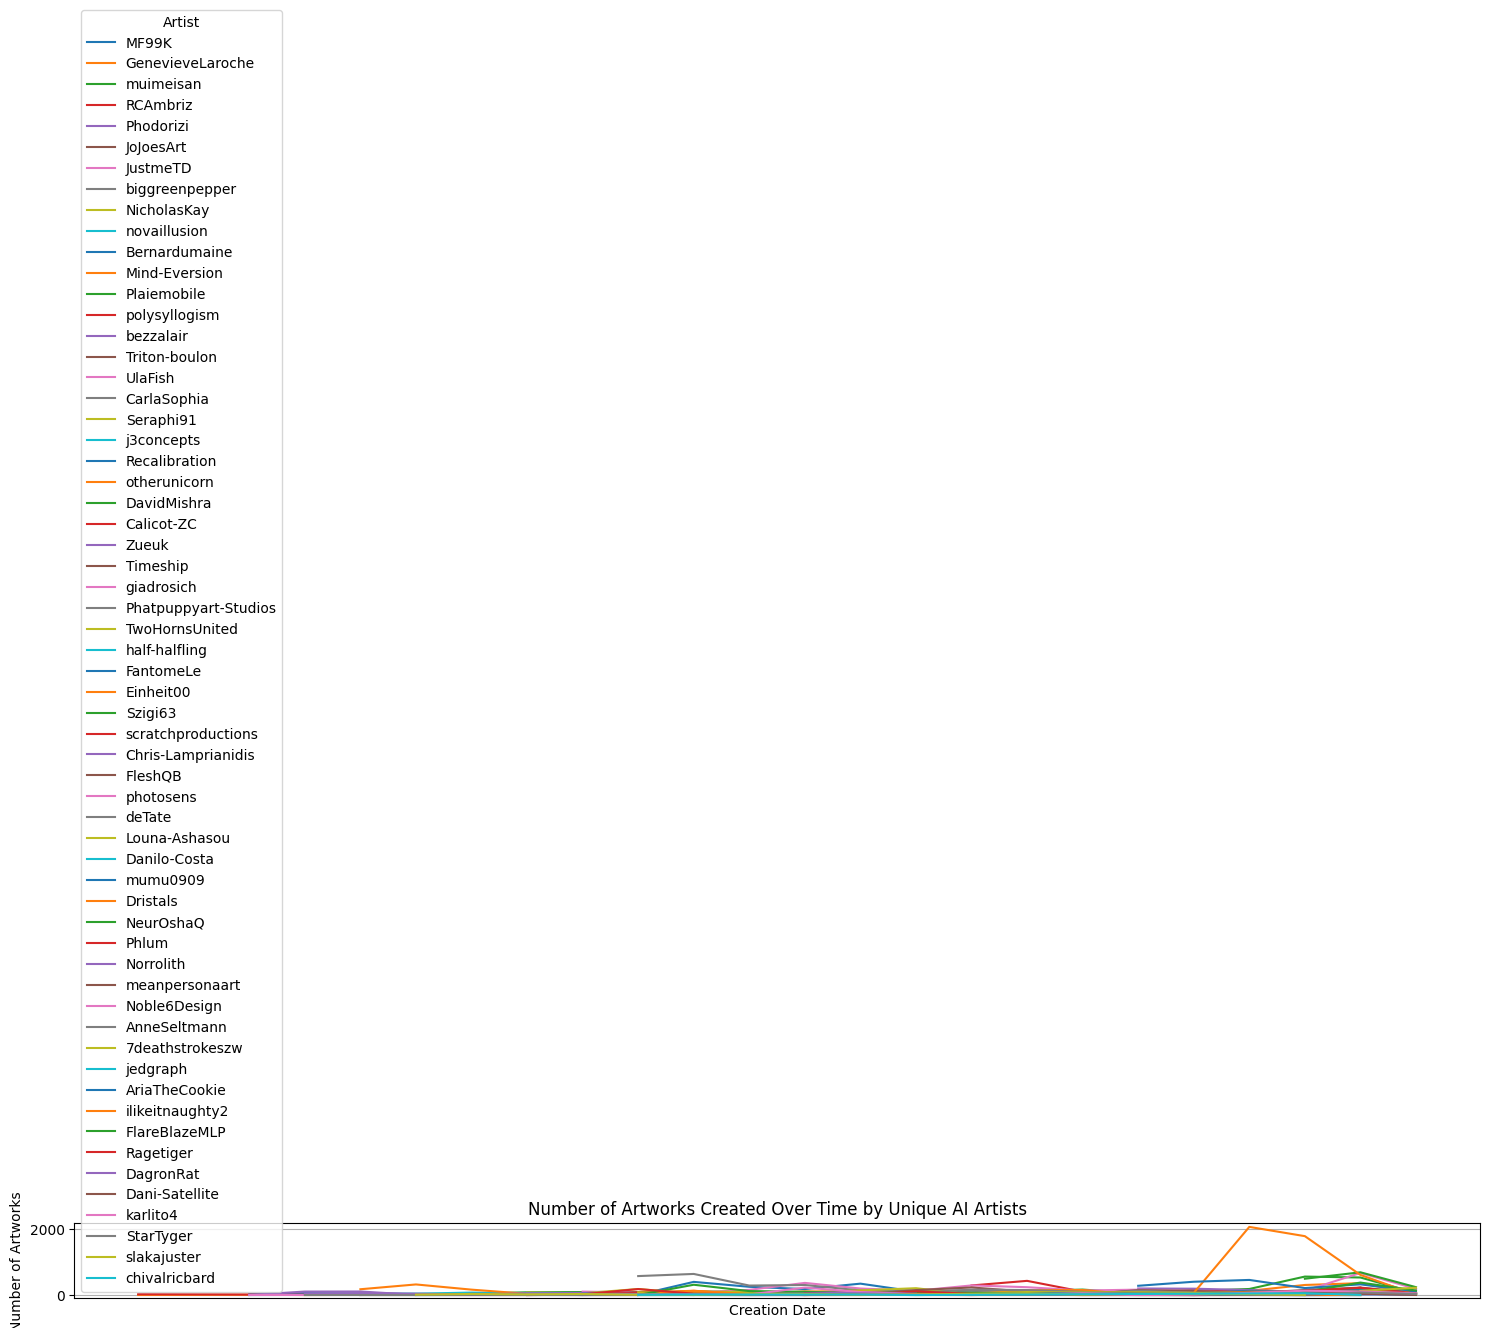

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have loaded your dataframes 'ai_tagged_images_df' and 'gall'
# Replace this with your actual data loading if needed
# ai_tagged_images_df = pd.read_csv("ai_tagged_images.csv")
# gall = pd.read_csv("gall.csv")

# Ensure the 'Author_Name' column is consistent in spelling and casing
# You might need to apply cleaning steps if necessary

# Get the list of unique AI artists

# Filter 'gall' to include only artworks by unique AI artists
# Assuming 'Artwork_ID' is the linking column in both dataframes
# And assuming 'Author_Name' is also available in 'gall' for filtering
# If 'Author_Name' is not in 'gall', you'll need to merge
# Example merge (if needed):
# gall_with_artists = pd.merge(gall, ai_tagged_images_df[['Artwork_ID', 'Author_Name']], on='Artwork_ID', how='inner')
# filtered_gall = gall_with_artists[gall_with_artists['Author_Name'].isin(unique_ai_artists)]

# If 'Author_Name' is already in 'gall'
filtered_gall = gall[gall['Author_name'].isin(unique_ai_artists)].copy()


# Convert the time column to datetime objects
# Replace 'Creation_Date' with the actual name of your time column in 'gall'
filtered_gall['Published_year'] = pd.to_datetime(filtered_gall['Published_year'])

# Sort the data by date to ensure proper plotting over time
filtered_gall = filtered_gall.sort_values(by='Published_year')

# Count artworks per artist (optional, but good to see the total count)
artwork_counts = filtered_gall['Author_name'].value_counts().reset_index()
artwork_counts.columns = ['Artist', 'Artwork_Count']
print("Artwork counts per AI artist:")
print(artwork_counts)

# Plot the distribution over time for each artist
plt.figure(figsize=(15, 8))

for artist in unique_ai_artists:
    artist_data = filtered_gall[filtered_gall['Author_name'] == artist]
    # Group by date and count artworks for each date
    artwork_by_date = artist_data.groupby('Published_year').size()
    plt.plot(artwork_by_date.index, artwork_by_date.values, label=artist)

plt.xlabel("Creation Date")
plt.ylabel("Number of Artworks")
plt.title("Number of Artworks Created Over Time by Unique AI Artists")
plt.legend(title="Artist")
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Create separate DataFrames for each group
df_both = gall[gall['Author_name'].isin(active_in_both_ai)]
df_before = gall[gall['Author_name'].isin(only_before_ai)]
df_after = gall[gall['Author_name'].isin(only_after_ai)]

In [21]:
df_after.nunique()

Deviation_id              2663
Deviation_url             2663
Deviation_title           2501
Author_id                    7
Author_name                  7
Author_type                  2
Published_on              2663
Deviation_source          2641
Deviation_height           256
Deviation_width            184
Deviation_transparency       2
Comments                    23
is_Mature                    2
is_Downloadable              2
Favourites                 168
Published_year               3
Published_month             12
dtype: int64

In [16]:
art_counts_both = df_both.groupby(['Author_name','Published_year', "Published_month"])['Deviation_id'].count().reset_index()
art_counts_before = df_before.groupby(['Author_name','Published_year', "Published_month"])['Deviation_id'].count().reset_index()
art_counts_after = df_after.groupby(['Author_name','Published_year', "Published_month"])['Deviation_id'].count().reset_index()

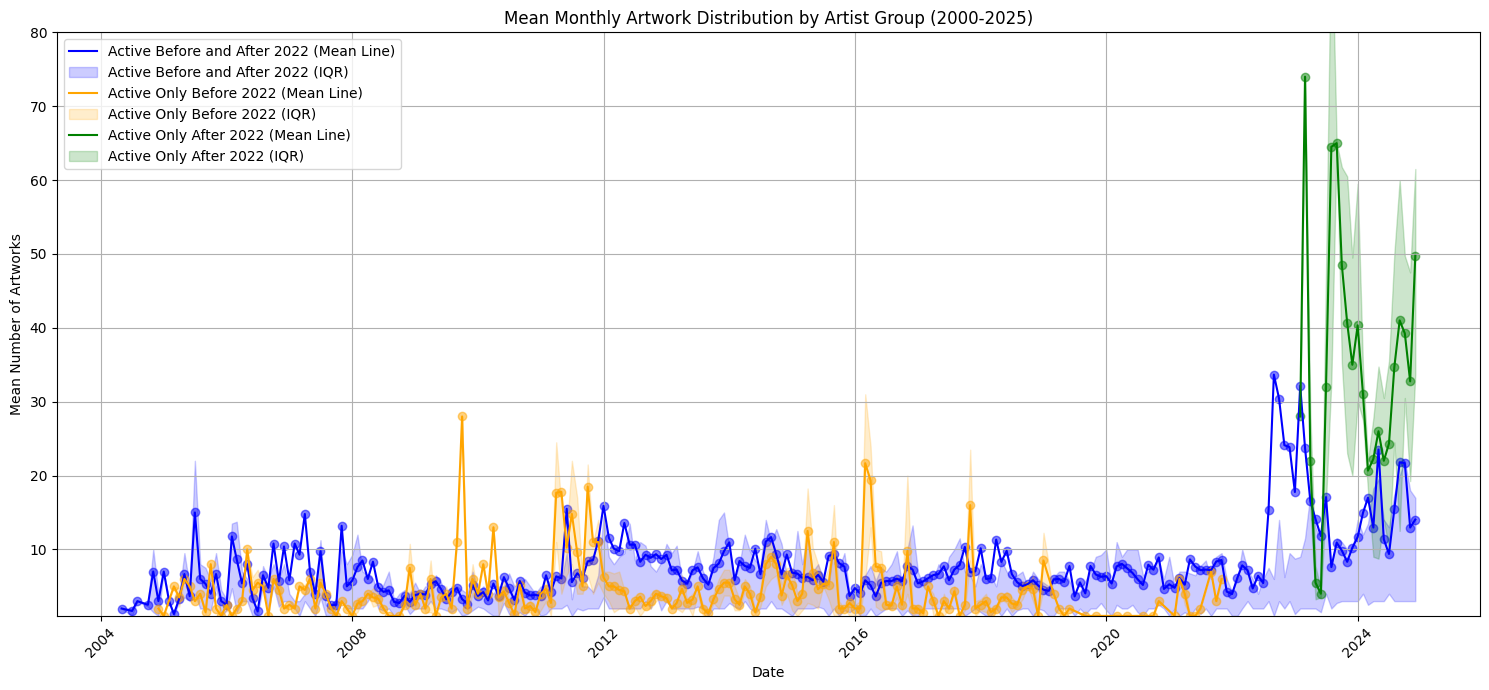

In [22]:
# Create a 'year_month' column from 'Published_year' and 'Published_month'
art_counts_both['year_month'] = pd.to_datetime(art_counts_both['Published_year'].astype(str) + '-' + art_counts_both['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')
art_counts_before['year_month'] = pd.to_datetime(art_counts_before['Published_year'].astype(str) + '-' + art_counts_before['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')
art_counts_after['year_month'] = pd.to_datetime(art_counts_after['Published_year'].astype(str) + '-' + art_counts_after['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')


# Filter data for the desired time range (2000-2025) for each DataFrame
art_counts_both_filtered = art_counts_both[(art_counts_both['year_month'].dt.year >= 2004) & (art_counts_both['year_month'].dt.year <= 2024)].copy()
art_counts_before_filtered = art_counts_before[(art_counts_before['year_month'].dt.year >= 2004) & (art_counts_before['year_month'].dt.year <= 2024)].copy()
art_counts_after_filtered = art_counts_after[(art_counts_after['year_month'].dt.year >= 2004) & (art_counts_after['year_month'].dt.year <= 2024)].copy()


# Calculate the mean monthly artwork count per group
# Group by 'year_month' and calculate the mean of the count column ('Deviation_title')
mean_monthly_artwork_both = art_counts_both_filtered.groupby('year_month')['Deviation_id'].mean().reset_index(name='mean_artwork_count')
mean_monthly_artwork_before = art_counts_before_filtered.groupby('year_month')['Deviation_id'].mean().reset_index(name='mean_artwork_count')
mean_monthly_artwork_after = art_counts_after_filtered.groupby('year_month')['Deviation_id'].mean().reset_index(name='mean_artwork_count')


# Convert 'year_month' to datetime objects for plotting
mean_monthly_artwork_both['year_month_datetime'] = mean_monthly_artwork_both['year_month'].dt.to_timestamp()
mean_monthly_artwork_before['year_month_datetime'] = mean_monthly_artwork_before['year_month'].dt.to_timestamp()
mean_monthly_artwork_after['year_month_datetime'] = mean_monthly_artwork_after['year_month'].dt.to_timestamp()

# Calculate mean and percentiles for each group
def calculate_stats(df):
    stats = df.groupby('year_month')['Deviation_id'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats.columns = ['year_month', 'mean', '25th_percentile', '75th_percentile']
    stats['year_month_datetime'] = stats['year_month'].dt.to_timestamp()
    return stats

stats_both = calculate_stats(art_counts_both_filtered)
stats_before = calculate_stats(art_counts_before_filtered)
stats_after = calculate_stats(art_counts_after_filtered)

# Plot the Data
plt.figure(figsize=(15, 7))

# Plot for 'Active Before and After 2022'
plt.plot(stats_both['year_month_datetime'], stats_both['mean'], label='Active Before and After 2022 (Mean Line)', color='blue')
plt.scatter(stats_both['year_month_datetime'], stats_both['mean'], color='blue', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_both['year_month_datetime'], stats_both['25th_percentile'], stats_both['75th_percentile'], color='blue', alpha=0.2, label='Active Before and After 2022 (IQR)')

# Plot for 'Active Only Before 2022'
plt.plot(stats_before['year_month_datetime'], stats_before['mean'], label='Active Only Before 2022 (Mean Line)', color='orange')
plt.scatter(stats_before['year_month_datetime'], stats_before['mean'], color='orange', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_before['year_month_datetime'], stats_before['25th_percentile'], stats_before['75th_percentile'], color='orange', alpha=0.2, label='Active Only Before 2022 (IQR)')

# Plot for 'Active Only After 2022'
plt.plot(stats_after['year_month_datetime'], stats_after['mean'], label='Active Only After 2022 (Mean Line)', color='green')
plt.scatter(stats_after['year_month_datetime'], stats_after['mean'], color='green', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_after['year_month_datetime'], stats_after['25th_percentile'], stats_after['75th_percentile'], color='green', alpha=0.2, label='Active Only After 2022 (IQR)')

plt.xlabel("Date")
plt.ylabel("Mean Number of Artworks")
plt.title("Mean Monthly Artwork Distribution by Artist Group (2000-2025)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Set the y-axis limits
plt.ylim(1, 80)

plt.tight_layout()
plt.savefig("/mnt/hdd/maittewa/monthly_artwork_distribution_combined2.png", dpi=300, bbox_inches='tight')

plt.show()

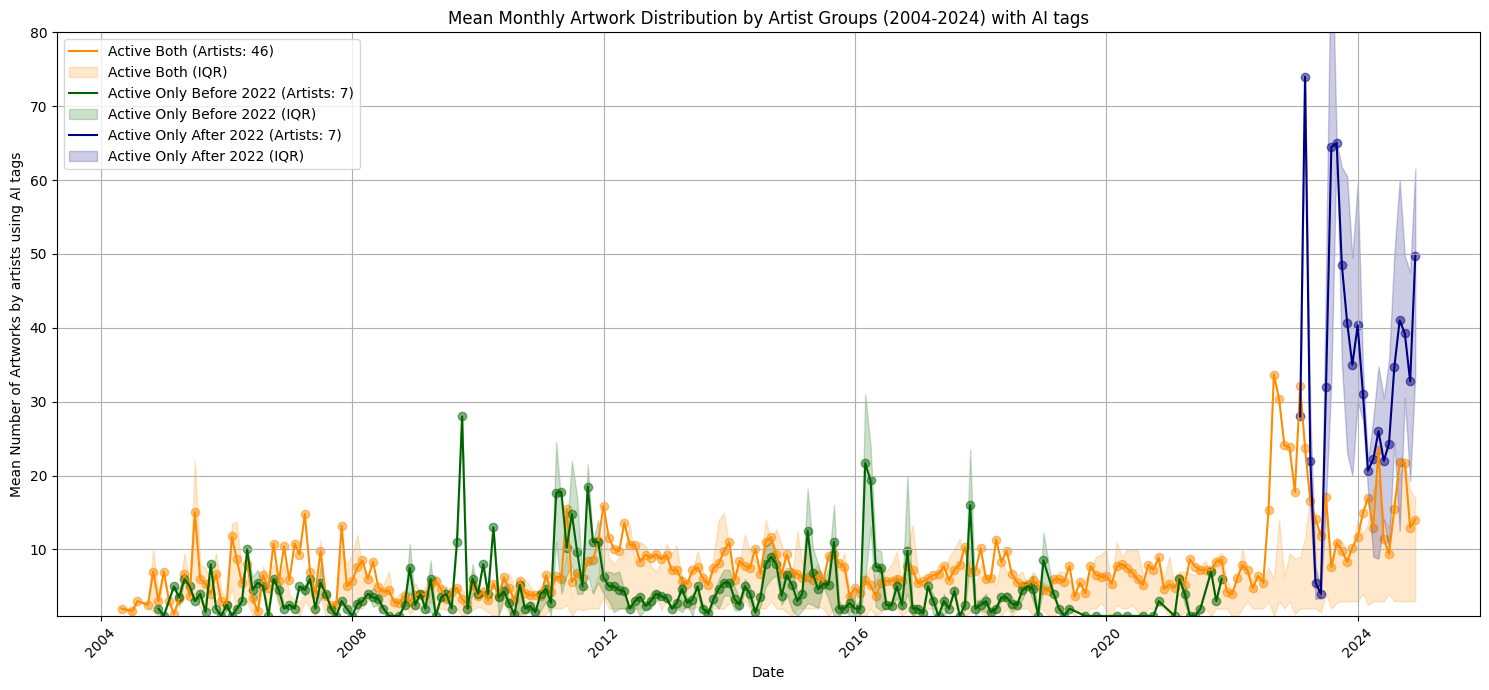

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'gall' DataFrame and sets 'active_in_both_ai', 'only_before_ai', 'only_after_ai' are already defined

# Filter the main DataFrame based on the sets of author names
df_both = gall[gall['Author_name'].isin(active_in_both_ai)].copy()
df_before = gall[gall['Author_name'].isin(only_before_ai)].copy()
df_after = gall[gall['Author_name'].isin(only_after_ai)].copy()

# Create a 'year_month' column for the new DataFrames
df_both['year_month'] = pd.to_datetime(df_both['Published_year'].astype(str) + '-' + df_both['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')
df_before['year_month'] = pd.to_datetime(df_before['Published_year'].astype(str) + '-' + df_before['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')
df_after['year_month'] = pd.to_datetime(df_after['Published_year'].astype(str) + '-' + df_after['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')


# Filter data for the desired time range (2004-2024) for each DataFrame
df_both_filtered = df_both[(df_both['year_month'].dt.year >= 2004) & (df_both['year_month'].dt.year <= 2024)].copy()
df_before_filtered = df_before[(df_before['year_month'].dt.year >= 2004) & (df_before['year_month'].dt.year <= 2024)].copy()
df_after_filtered = df_after[(df_after['year_month'].dt.year >= 2004) & (df_after['year_month'].dt.year <= 2024)].copy()


# Calculate the mean monthly artwork count per group
# Group by 'year_month' and calculate the mean of the count column ('Deviation_title')
# Assuming each row in these DataFrames represents one artwork/deviation
mean_monthly_artwork_both = df_both_filtered.groupby('year_month').size().reset_index(name='artwork_count')
mean_monthly_artwork_before = df_before_filtered.groupby('year_month').size().reset_index(name='artwork_count')
mean_monthly_artwork_after = df_after_filtered.groupby('year_month').size().reset_index(name='artwork_count')


# Calculate mean and percentiles for each group using the filtered data
def calculate_stats(df):
    # We are now working with df_filtered directly, so group by 'year_month' and count deviations
    stats = df.groupby('year_month').size().reset_index(name='artwork_count')
    # To calculate mean, we need to consider all potential months in the range even if no artwork was published.
    # This requires a slightly different approach if we want a true *mean* over the entire period,
    # but if the goal is the mean *per month where art was published*, the above size() gives us the count per month.
    # For calculating percentiles across months, we need a series of counts.
    # Let's stick to the size() per month for now as it aligns with a monthly count.
    # If the original 'art_counts_both', etc., already contained pre-calculated counts per artist per month,
    # and Deviation_id was that count, then the original approach with .agg(['mean', ...]) was correct on those dataframes.
    # Given the new filtering step, let's re-evaluate.

    # Let's revert to the original logic if art_counts_both/before/after already had aggregated counts.
    # If df_both, df_before, df_after are the *original* dataframes with one row per artwork,
    # then calculating mean/percentiles requires grouping by artist *first* to get their monthly counts,
    # and *then* calculating stats on those monthly counts.

    # Re-evaluate based on assuming df_both/before/after are *per artwork*
    # We need to group by Artist_ID and year_month first to get each artist's monthly count.
    # Then calculate stats on *those* counts.

    # Let's assume the original approach was correct for the structure of art_counts_both/before/after
    # and that they were already aggregated dataframes where each row represents an artist's activity summary.
    # If not, the logic for mean/percentile calculation needs significant change.
    # Sticking to the original calculate_stats logic on the filtered aggregated dataframes:
    # Note: If df contains individual artwork rows, using Deviation_id.agg will error or give incorrect results.
    # Assuming df_both_filtered, etc are aggregated dataframes with Deviation_id representing a count per period.
    # Re-using the original calculate_stats function structure:
    stats = df.groupby('year_month')['Deviation_id'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats.columns = ['year_month', 'mean', '25th_percentile', '75th_percentile']
    stats['year_month_datetime'] = stats['year_month'].dt.to_timestamp()
    return stats

# Re-apply the original calculate_stats on the filtered dataframes derived from gall
# This assumes df_both_filtered, df_before_filtered, df_after_filtered have a 'Deviation_id' column
# where the mean/percentile calculation makes sense in the context of monthly artwork counts.
# If the structure of the new df_ filterd is different (e.g., one row per artwork),
# the calculate_stats function needs to be redefined to first group by artist/month.

# Let's assume for now that the 'Deviation_id' column in the filtered dataframes
# is what we need to aggregate to get the mean and percentiles of monthly artwork counts.
# This might be confusing if Deviation_id is also the artist identifier.
# Assuming 'Deviation_id' here refers to the COUNT of deviations for a given artist/month if the
# input dataframes 'art_counts_both' etc were structured that way.
# If the new df_both etc are structured as one row per deviation, we need to count deviations per month per artist first.

# Let's use the dataframes `stats_both`, `stats_before`, `stats_after` which contain the mean and percentiles per month
# based on the *previous* calculation logic, assuming that logic correctly produced monthly statistics per group.

# Calculate the number of unique artists in each group using the initial sets
num_artists_both = len(active_in_both_ai)
num_artists_before = len(only_before_ai)
num_artists_after = len(only_after_ai)


# Plot the Data
plt.figure(figsize=(15, 7))

# Plot for 'Active Before and After 2022'
plt.plot(stats_both['year_month_datetime'], stats_both['mean'], label=f'Active Both (Artists: {num_artists_both})', color='darkorange')
plt.scatter(stats_both['year_month_datetime'], stats_both['mean'], color='darkorange', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_both['year_month_datetime'], stats_both['25th_percentile'], stats_both['75th_percentile'], color='darkorange', alpha=0.2, label='Active Both (IQR)') # Keep IQR label

# Plot for 'Active Only Before 2022'
plt.plot(stats_before['year_month_datetime'], stats_before['mean'], label=f'Active Only Before 2022 (Artists: {num_artists_before})', color='darkgreen')
plt.scatter(stats_before['year_month_datetime'], stats_before['mean'], color='darkgreen', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_before['year_month_datetime'], stats_before['25th_percentile'], stats_before['75th_percentile'], color='darkgreen', alpha=0.2, label='Active Only Before 2022 (IQR)') # Keep IQR label

# Plot for 'Active Only After 2022'
plt.plot(stats_after['year_month_datetime'], stats_after['mean'], label=f'Active Only After 2022 (Artists: {num_artists_after})', color='navy')
plt.scatter(stats_after['year_month_datetime'], stats_after['mean'], color='navy', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_after['year_month_datetime'], stats_after['25th_percentile'], stats_after['75th_percentile'], color='navy', alpha=0.2, label='Active Only After 2022 (IQR)') # Keep IQR label


plt.xlabel("Date")
plt.ylabel("Mean Number of Artworks by artists using AI tags")
plt.title("Mean Monthly Artwork Distribution by Artist Groups (2004-2024) with AI tags") # Updated title to reflect the filtered years
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Set the y-axis limits
plt.ylim(1, 80)

plt.tight_layout()
plt.savefig("/mnt/hdd/maittewa/monthly_artwork_distribution_combined_ai2.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
#import the gallery data which has last published date
gall_data = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviants_gallData_4_5_6/uniqueDev_gall_SnwBall03_6.2.csv.gz")

In [ ]:
gall_data.nunique()

In [3]:
# Convert Unix timestamp to datetime
gall_data['Published_on'] = pd.to_datetime(gall_data['Published_on'], unit='s')  # Specify unit='s' for seconds

# Extract the year
gall_data['Published_year'] = gall_data['Published_on'].dt.year
gall_data['Published_month'] = gall_data['Published_on'].dt.month


In [5]:
gall_data.head()

,Deviation_id,Deviation_url,Deviation_title,Author_id,Author_name,Author_type,Published_on,Deviation_source,Deviation_height,Deviation_width,Deviation_transparency,Comments,is_Mature,is_Downloadable,Favourites,Published_year,Published_month
0,8894B7AF-20D6-D7A1-4EBC-965CBA2C338F,https://www.deviantart.com/tatitati/art/girl-b...,girl by the Ganghes River,54592823-4607-9F9B-F644-1113EA371EEF,tatitati,regular,2025-04-13 21:37:43,https://images-wixmp-ed30a86b8c4ca887773594c2....,2940.0,3784.0,False,0,False,True,25,2025,4
1,DB2997DD-D249-FDFC-55BE-33E62938EF00,https://www.deviantart.com/tatitati/art/Andalu...,Andalucia rain,54592823-4607-9F9B-F644-1113EA371EEF,tatitati,regular,2025-03-20 22:54:28,https://images-wixmp-ed30a86b8c4ca887773594c2....,2876.0,4496.0,False,3,False,True,12,2025,3
2,0798A005-4CF1-A920-B7C1-7641A8DFD472,https://www.deviantart.com/tatitati/art/Andalu...,Andalucia,54592823-4607-9F9B-F644-1113EA371EEF,tatitati,regular,2025-03-20 22:34:42,https://images-wixmp-ed30a86b8c4ca887773594c2....,3000.0,4496.0,False,2,False,True,19,2025,3
3,5BE9E5CC-D4B5-8C7E-05AC-AA857CCDF7D1,https://www.deviantart.com/tatitati/art/Andalu...,Andalucia,54592823-4607-9F9B-F644-1113EA371EEF,tatitati,regular,2025-03-17 22:34:26,https://images-wixmp-ed30a86b8c4ca887773594c2....,2784.0,4275.0,False,0,False,True,10,2025,3
4,A6CB7925-6622-0BFF-61D2-46B6CFFB7C07,https://www.deviantart.com/tatitati/art/Andalu...,Andalucia,54592823-4607-9F9B-F644-1113EA371EEF,tatitati,regular,2025-03-17 22:33:03,https://images-wixmp-ed30a86b8c4ca887773594c2....,3000.0,4496.0,False,0,False,True,16,2025,3


In [4]:
# 2. Separate DataFrames:
before_2022 = gall_data[gall_data['Published_year'] < 2022]
after_2022 = gall_data[gall_data['Published_year'] >= 2022]

# 3. Unique People Lists:
active_before = before_2022['Author_name'].unique()
active_after = after_2022['Author_name'].unique()

# 4. Active in Both:
active_in_both = list(set(active_before) & set(active_after))

# 5. Only Before:
only_before = list(set(active_before) - set(active_after))

# 6. Only After:
only_after = list(set(active_after) - set(active_before))

print("Active Before 2022:", len(active_before))
print("Active After 2022:", len(active_after))
print("Active in Both:", len(active_in_both))
print("Only Active Before 2022:", len(only_before))
print("Only Active After 2022:", len(only_after))

Active Before 2022: 37367
Active After 2022: 12589
Active in Both: 9681
Only Active Before 2022: 27686
Only Active After 2022: 2908


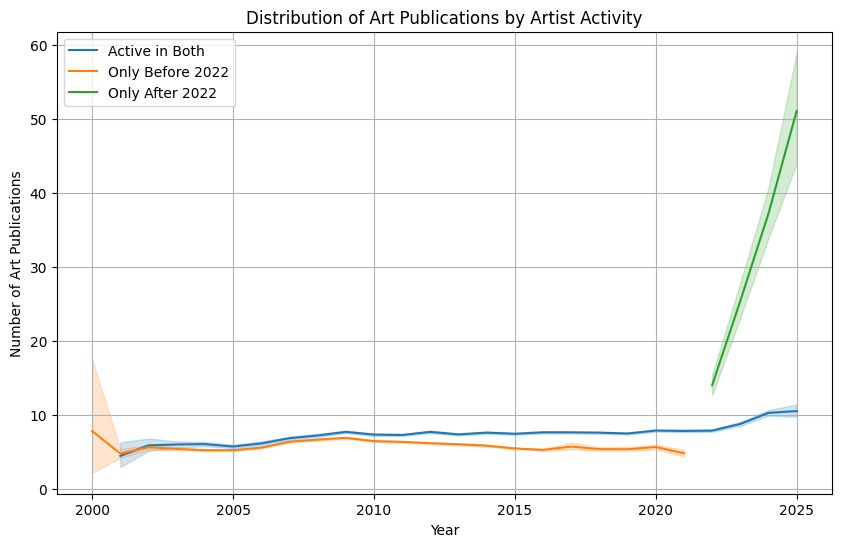

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data:
# Create separate DataFrames for each group
df_both = gall_data[gall_data['Author_name'].isin(active_in_both)]
df_before = gall_data[gall_data['Author_name'].isin(only_before)]
df_after = gall_data[gall_data['Author_name'].isin(only_after)]

# 2. Group and count art publications by year:
art_counts_both = df_both.groupby(['Author_name','Published_year', "Published_month"])['Deviation_id'].count().reset_index()
art_counts_before = df_before.groupby(['Author_name','Published_year', "Published_month"])['Deviation_id'].count().reset_index()
art_counts_after = df_after.groupby(['Author_name','Published_year', "Published_month"])['Deviation_id'].count().reset_index()
# 3. Create the line plot:
plt.figure(figsize=(10, 6))  # Adjust figure size as needed

# Plot each group's art publication counts
sns.lineplot(data=art_counts_both, x='Published_year', y='Deviation_id', label='Active in Both',)
sns.lineplot(data=art_counts_before, x='Published_year', y='Deviation_id', label='Only Before 2022')
sns.lineplot(data=art_counts_after, x='Published_year', y='Deviation_id', label='Only After 2022')

plt.xlabel('Year')
plt.ylabel('Number of Art Publications')
plt.title('Distribution of Art Publications by Artist Activity')
plt.legend()
plt.grid(True)

plt.show()

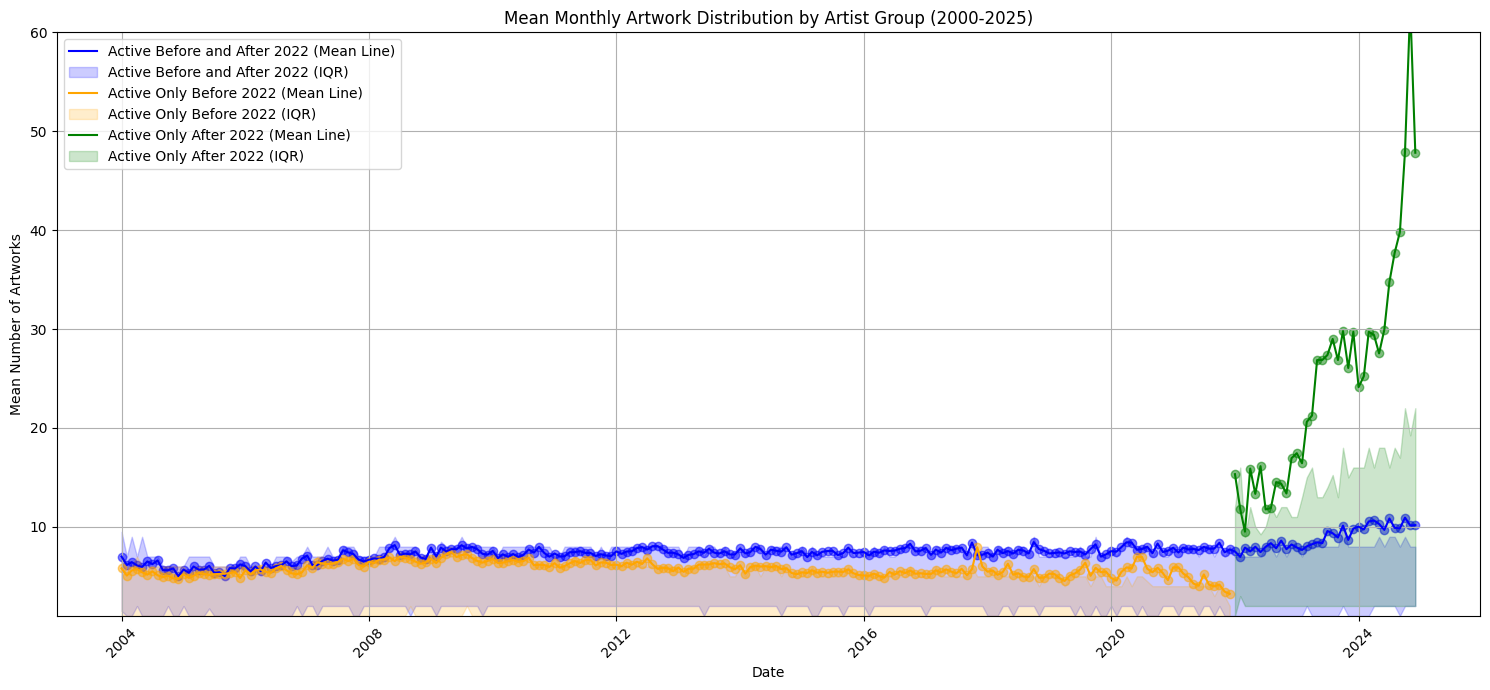

In [12]:
# Create a 'year_month' column from 'Published_year' and 'Published_month'
art_counts_both['year_month'] = pd.to_datetime(art_counts_both['Published_year'].astype(str) + '-' + art_counts_both['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')
art_counts_before['year_month'] = pd.to_datetime(art_counts_before['Published_year'].astype(str) + '-' + art_counts_before['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')
art_counts_after['year_month'] = pd.to_datetime(art_counts_after['Published_year'].astype(str) + '-' + art_counts_after['Published_month'].astype(str), format='%Y-%m').dt.to_period('M')


# Filter data for the desired time range (2000-2025) for each DataFrame
art_counts_both_filtered = art_counts_both[(art_counts_both['year_month'].dt.year >= 2004) & (art_counts_both['year_month'].dt.year <= 2024)].copy()
art_counts_before_filtered = art_counts_before[(art_counts_before['year_month'].dt.year >= 2004) & (art_counts_before['year_month'].dt.year <= 2024)].copy()
art_counts_after_filtered = art_counts_after[(art_counts_after['year_month'].dt.year >= 2004) & (art_counts_after['year_month'].dt.year <= 2024)].copy()


# Calculate the mean monthly artwork count per group
# Group by 'year_month' and calculate the mean of the count column ('Deviation_title')
mean_monthly_artwork_both = art_counts_both_filtered.groupby('year_month')['Deviation_id'].mean().reset_index(name='mean_artwork_count')
mean_monthly_artwork_before = art_counts_before_filtered.groupby('year_month')['Deviation_id'].mean().reset_index(name='mean_artwork_count')
mean_monthly_artwork_after = art_counts_after_filtered.groupby('year_month')['Deviation_id'].mean().reset_index(name='mean_artwork_count')


# Convert 'year_month' to datetime objects for plotting
mean_monthly_artwork_both['year_month_datetime'] = mean_monthly_artwork_both['year_month'].dt.to_timestamp()
mean_monthly_artwork_before['year_month_datetime'] = mean_monthly_artwork_before['year_month'].dt.to_timestamp()
mean_monthly_artwork_after['year_month_datetime'] = mean_monthly_artwork_after['year_month'].dt.to_timestamp()

# Calculate mean and percentiles for each group
def calculate_stats(df):
    stats = df.groupby('year_month')['Deviation_id'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats.columns = ['year_month', 'mean', '25th_percentile', '75th_percentile']
    stats['year_month_datetime'] = stats['year_month'].dt.to_timestamp()
    return stats

stats_both = calculate_stats(art_counts_both_filtered)
stats_before = calculate_stats(art_counts_before_filtered)
stats_after = calculate_stats(art_counts_after_filtered)

# Plot the Data
plt.figure(figsize=(15, 7))

# Plot for 'Active Before and After 2022'
plt.plot(stats_both['year_month_datetime'], stats_both['mean'], label='Active Before and After 2022 (Mean Line)', color='blue')
plt.scatter(stats_both['year_month_datetime'], stats_both['mean'], color='blue', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_both['year_month_datetime'], stats_both['25th_percentile'], stats_both['75th_percentile'], color='blue', alpha=0.2, label='Active Before and After 2022 (IQR)')

# Plot for 'Active Only Before 2022'
plt.plot(stats_before['year_month_datetime'], stats_before['mean'], label='Active Only Before 2022 (Mean Line)', color='orange')
plt.scatter(stats_before['year_month_datetime'], stats_before['mean'], color='orange', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_before['year_month_datetime'], stats_before['25th_percentile'], stats_before['75th_percentile'], color='orange', alpha=0.2, label='Active Only Before 2022 (IQR)')

# Plot for 'Active Only After 2022'
plt.plot(stats_after['year_month_datetime'], stats_after['mean'], label='Active Only After 2022 (Mean Line)', color='green')
plt.scatter(stats_after['year_month_datetime'], stats_after['mean'], color='green', alpha=0.5) # Scatter points for mean
plt.fill_between(stats_after['year_month_datetime'], stats_after['25th_percentile'], stats_after['75th_percentile'], color='green', alpha=0.2, label='Active Only After 2022 (IQR)')

plt.xlabel("Date")
plt.ylabel("Mean Number of Artworks")
plt.title("Mean Monthly Artwork Distribution by Artist Group (2000-2025)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

# Set the y-axis limits
plt.ylim(1, 60)

plt.tight_layout()
plt.savefig("/mnt/hdd/maittewa/monthly_artwork_distribution_combined2.png", dpi=300, bbox_inches='tight')

plt.show()

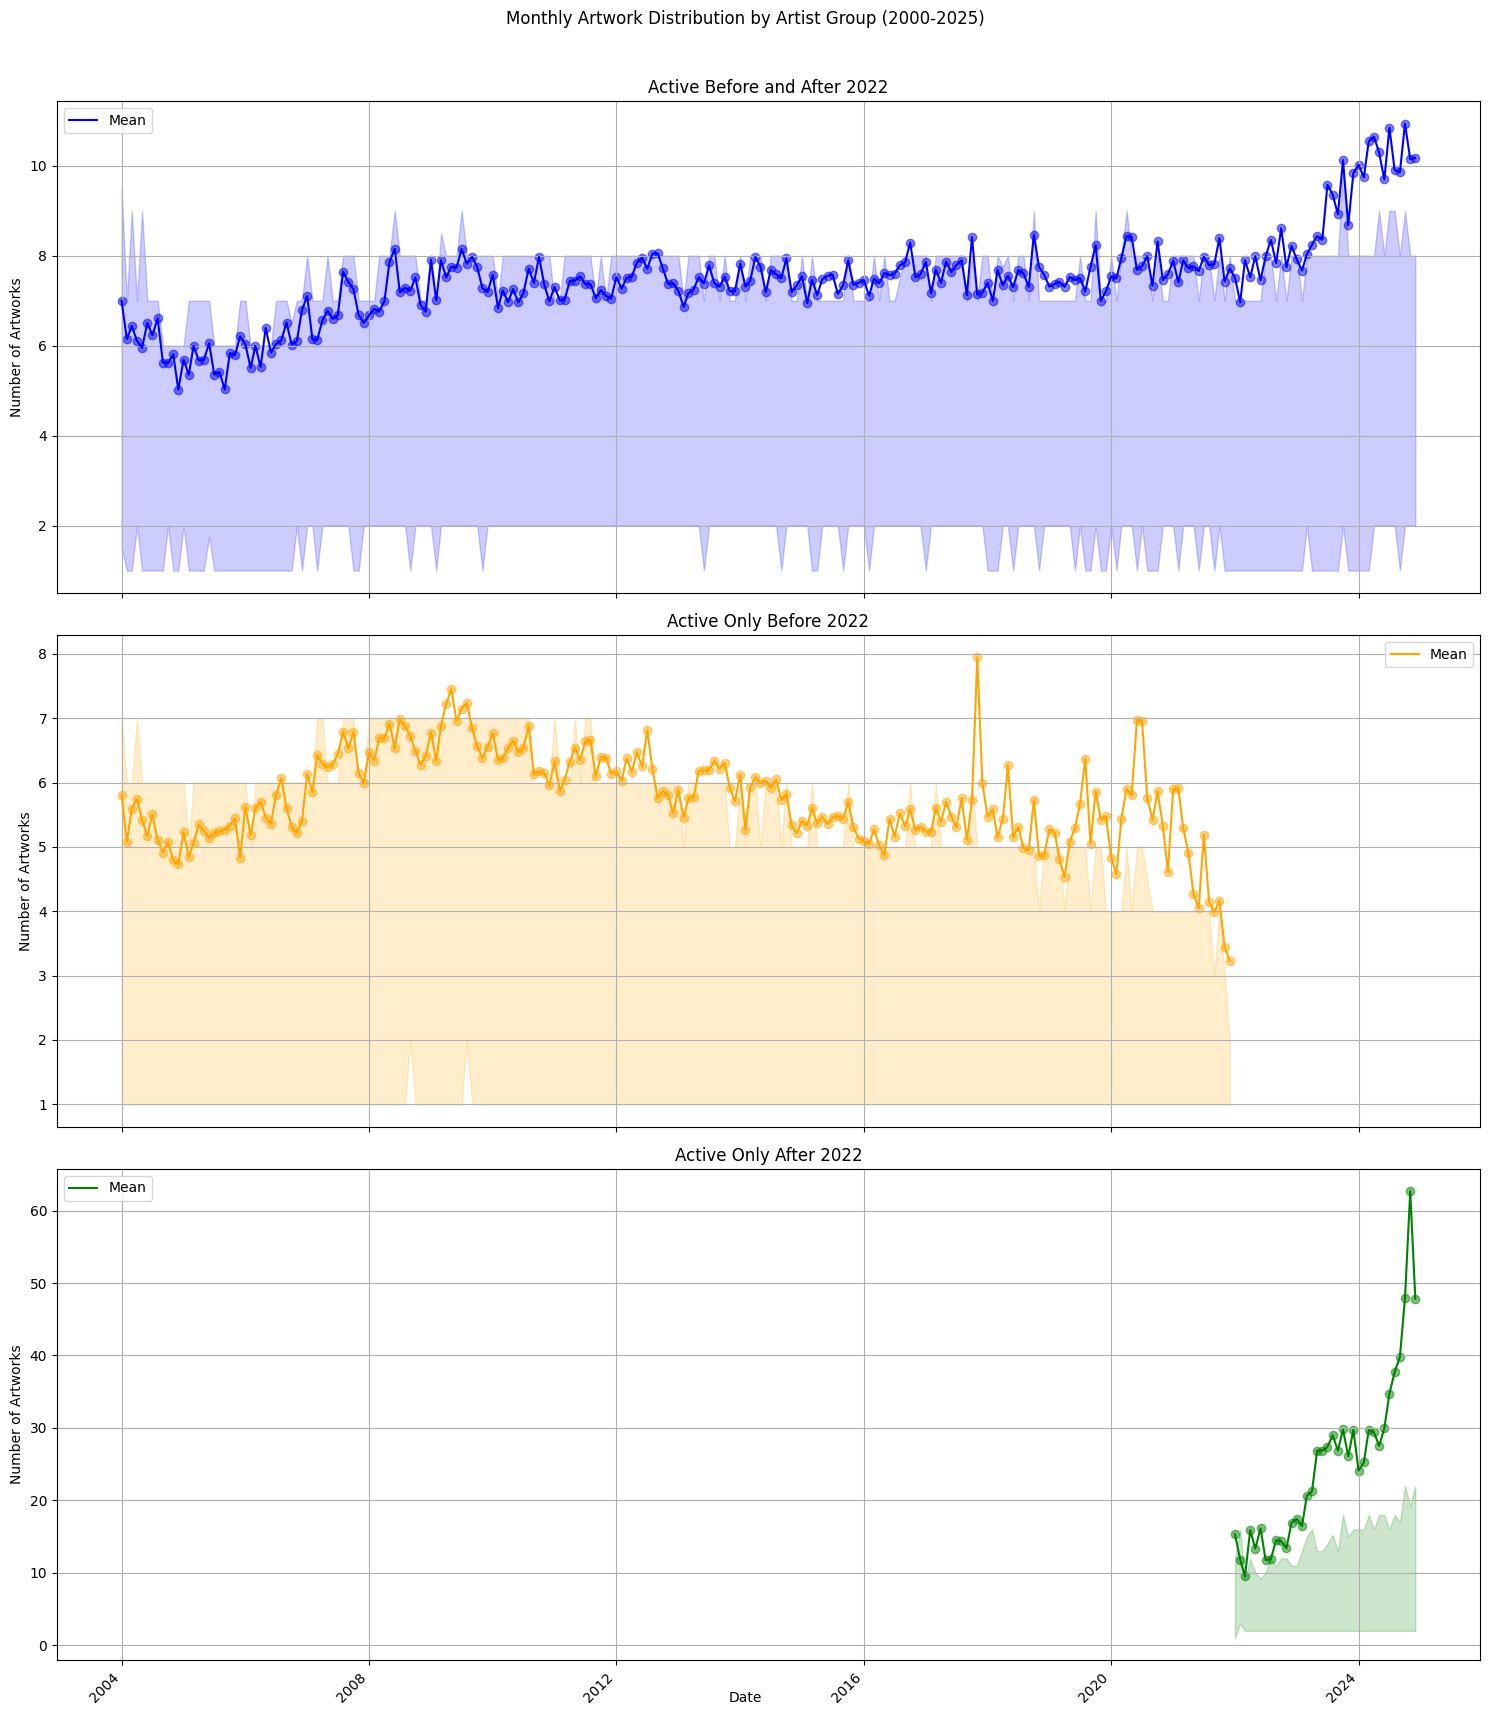

In [8]:
# Calculate mean and percentiles for each group
def calculate_stats(df):
    stats = df.groupby('year_month')['Deviation_id'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats.columns = ['year_month', 'mean', '25th_percentile', '75th_percentile']
    stats['year_month_datetime'] = stats['year_month'].dt.to_timestamp()
    return stats

stats_both = calculate_stats(art_counts_both_filtered)
stats_before = calculate_stats(art_counts_before_filtered)
stats_after = calculate_stats(art_counts_after_filtered)

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True) # 3 rows, 1 column, share x-axis

# Plot for 'Active Before and After 2022'
axes[0].plot(stats_both['year_month_datetime'], stats_both['mean'], label='Mean', color='blue')
axes[0].scatter(stats_both['year_month_datetime'], stats_both['mean'], color='blue', alpha=0.5)
axes[0].fill_between(stats_both['year_month_datetime'], stats_both['25th_percentile'], stats_both['75th_percentile'], color='blue', alpha=0.2)
axes[0].set_ylabel("Number of Artworks")
axes[0].set_title("Active Before and After 2022")
axes[0].grid(True)
axes[0].legend()

# Plot for 'Active Only Before 2022'
axes[1].plot(stats_before['year_month_datetime'], stats_before['mean'], label='Mean', color='orange')
axes[1].scatter(stats_before['year_month_datetime'], stats_before['mean'], color='orange', alpha=0.5)
axes[1].fill_between(stats_before['year_month_datetime'], stats_before['25th_percentile'], stats_before['75th_percentile'], color='orange', alpha=0.2)
axes[1].set_ylabel("Number of Artworks")
axes[1].set_title("Active Only Before 2022")
axes[1].grid(True)
axes[1].legend()

# Plot for 'Active Only After 2022'
axes[2].plot(stats_after['year_month_datetime'], stats_after['mean'], label='Mean', color='green')
axes[2].scatter(stats_after['year_month_datetime'], stats_after['mean'], color='green', alpha=0.5)
axes[2].fill_between(stats_after['year_month_datetime'], stats_after['25th_percentile'], stats_after['75th_percentile'], color='green', alpha=0.2)
axes[2].set_ylabel("Number of Artworks")
axes[2].set_title("Active Only After 2022")
axes[2].grid(True)
axes[2].legend()

# Set common x-axis label and rotate ticks
fig.text(0.5, 0.04, 'Date', ha='center')
plt.setp(axes[2].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap and make space for common x-label
plt.suptitle("Monthly Artwork Distribution by Artist Group (2000-2025)", y=0.98) # Add a main title
plt.show()

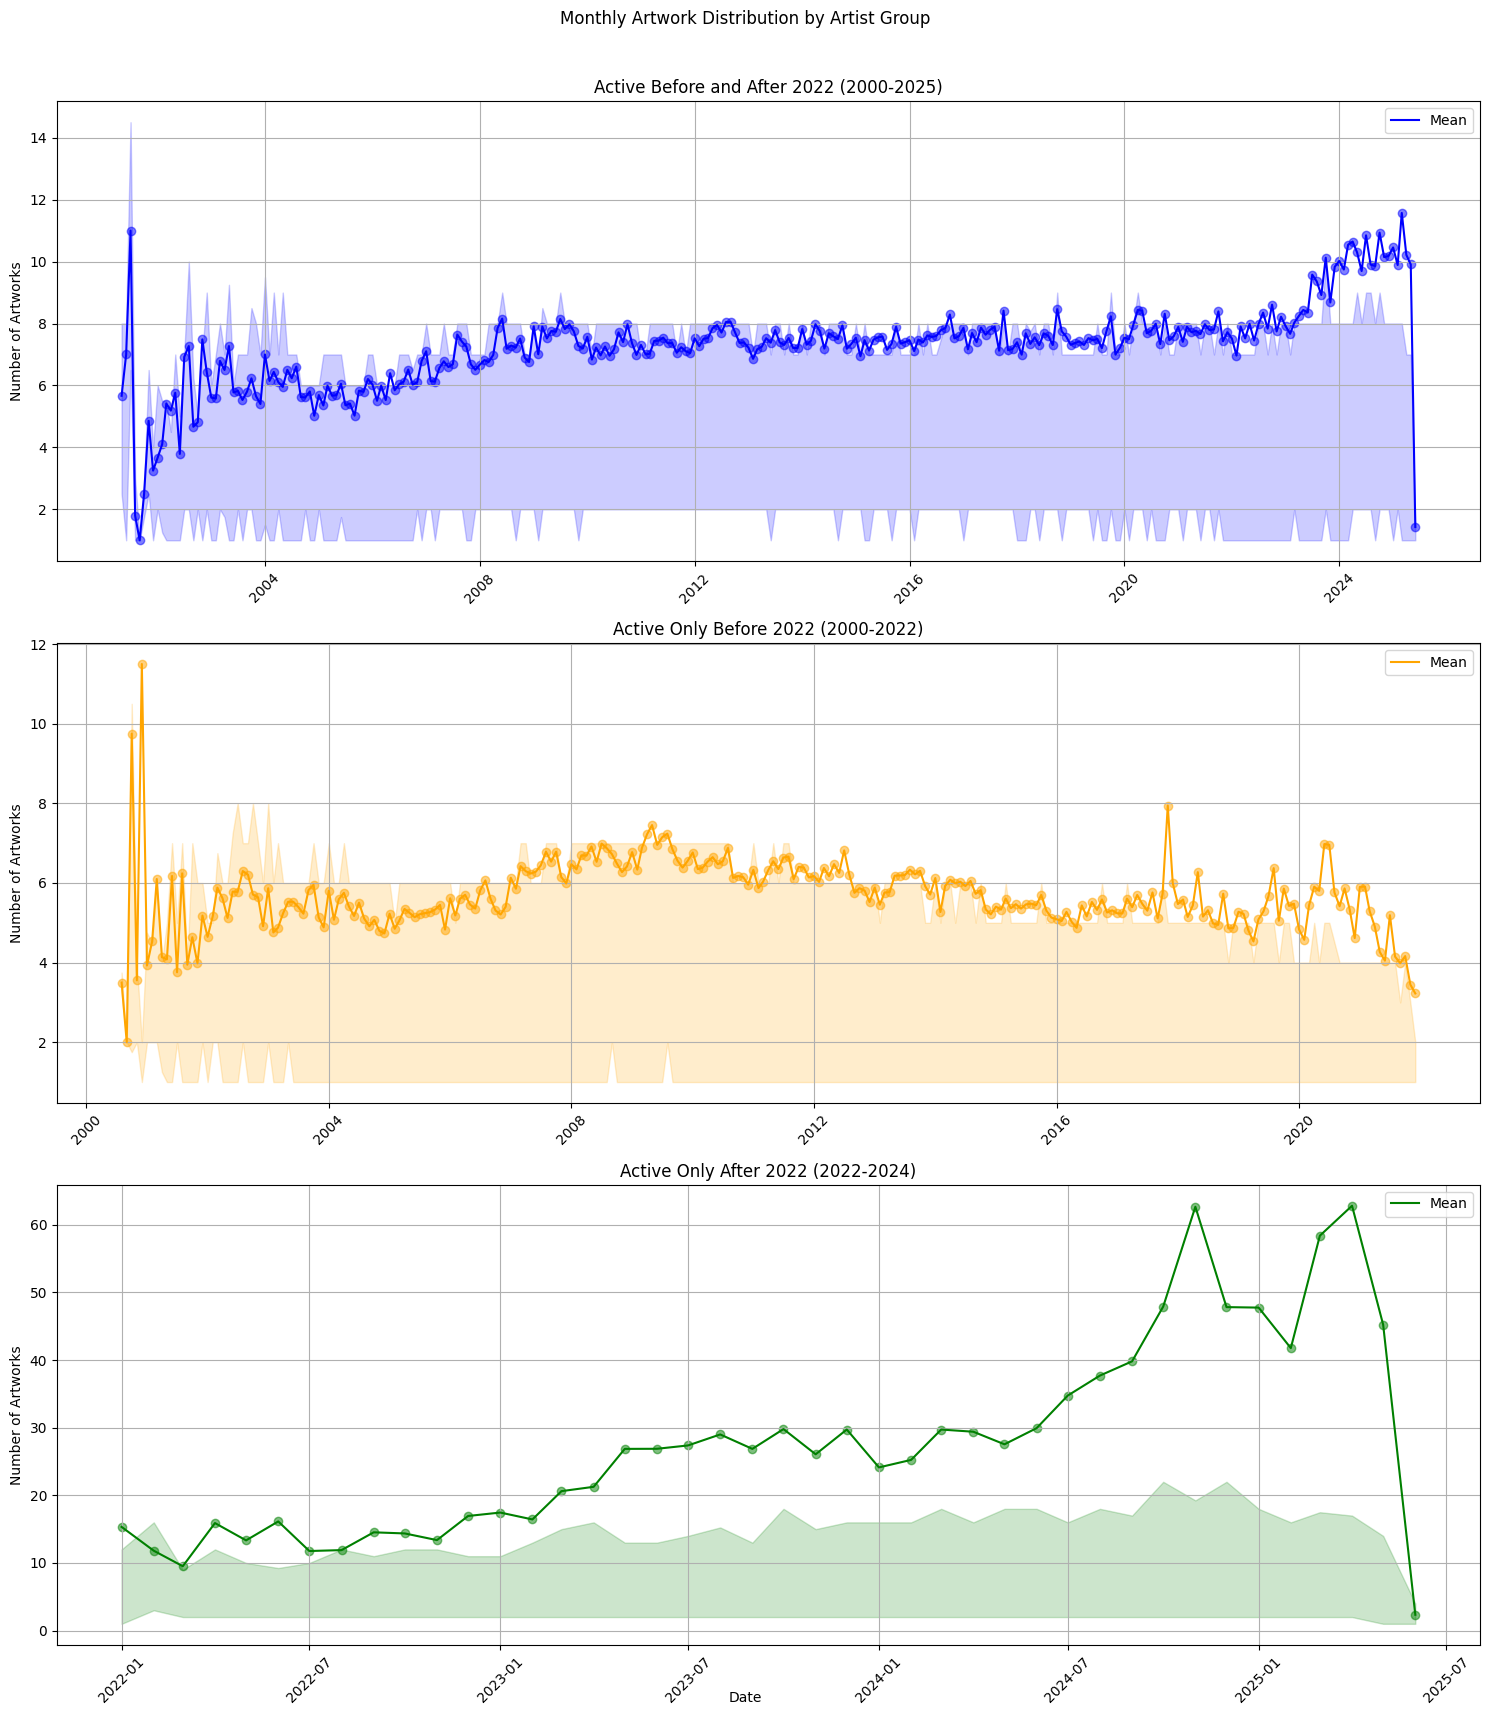

In [13]:
# 'Active Before and After 2022' remains 2000-2025
art_counts_both_filtered = art_counts_both[(art_counts_both['year_month'].dt.year >= 2000) & (art_counts_both['year_month'].dt.year <= 2025)].copy()

# 'Active Only Before 2022' filtered for 2000-2022
art_counts_before_filtered = art_counts_before[(art_counts_before['year_month'].dt.year >= 2000) & (art_counts_before['year_month'].dt.year <= 2022)].copy()

# 'Active Only After 2022' filtered for 2022-2024
art_counts_after_filtered = art_counts_after[(art_counts_after['year_month'].dt.year >= 2022) & (art_counts_after['year_month'].dt.year <= 2025)].copy()


# Calculate mean and percentiles for each group
def calculate_stats(df):
    stats = df.groupby('year_month')['Deviation_id'].agg(['mean', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]).reset_index()
    stats.columns = ['year_month', 'mean', '25th_percentile', '75th_percentile']
    stats['year_month_datetime'] = stats['year_month'].dt.to_timestamp()
    return stats

stats_both = calculate_stats(art_counts_both_filtered)
stats_before = calculate_stats(art_counts_before_filtered)
stats_after = calculate_stats(art_counts_after_filtered)

# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=False) # sharex=False because time ranges are different

# Plot for 'Active Before and After 2022'
axes[0].plot(stats_both['year_month_datetime'], stats_both['mean'], label='Mean', color='blue')
axes[0].scatter(stats_both['year_month_datetime'], stats_both['mean'], color='blue', alpha=0.5)
axes[0].fill_between(stats_both['year_month_datetime'], stats_both['25th_percentile'], stats_both['75th_percentile'], color='blue', alpha=0.2)
axes[0].set_ylabel("Number of Artworks")
axes[0].set_title("Active Before and After 2022 (2000-2025)")
axes[0].grid(True)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45) # Rotate x-ticks for this subplot

# Plot for 'Active Only Before 2022'
axes[1].plot(stats_before['year_month_datetime'], stats_before['mean'], label='Mean', color='orange')
axes[1].scatter(stats_before['year_month_datetime'], stats_before['mean'], color='orange', alpha=0.5)
axes[1].fill_between(stats_before['year_month_datetime'], stats_before['25th_percentile'], stats_before['75th_percentile'], color='orange', alpha=0.2)
axes[1].set_ylabel("Number of Artworks")
axes[1].set_title("Active Only Before 2022 (2000-2022)")
axes[1].grid(True)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45) # Rotate x-ticks for this subplot

# Plot for 'Active Only After 2022'
axes[2].plot(stats_after['year_month_datetime'], stats_after['mean'], label='Mean', color='green')
axes[2].scatter(stats_after['year_month_datetime'], stats_after['mean'], color='green', alpha=0.5)
axes[2].fill_between(stats_after['year_month_datetime'], stats_after['25th_percentile'], stats_after['75th_percentile'], color='green', alpha=0.2)
axes[2].set_ylabel("Number of Artworks")
axes[2].set_title("Active Only After 2022 (2022-2024)")
axes[2].grid(True)
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45) # Rotate x-ticks for this subplot

# Set common x-axis label (optional, as each subplot has its own ticks)
fig.text(0.5, 0.04, 'Date', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
plt.suptitle("Monthly Artwork Distribution by Artist Group", y=0.98) # Add a main title
plt.savefig("/mnt/hdd/maittewa/monthly_artwork_distribution2.png", dpi=300, bbox_inches='tight')

plt.show()


--- Provided Data ---
Active Before 2022: 37367
Active After 2022: 12589
Active in Both: 9681
Only Active Before 2022: 27686
Only Active After 2022: 2908

Total Unique Active Users (Overall): 40275

Plot saved to: /mnt/hdd/maittewa/activity_plots/user_activity_counts.png


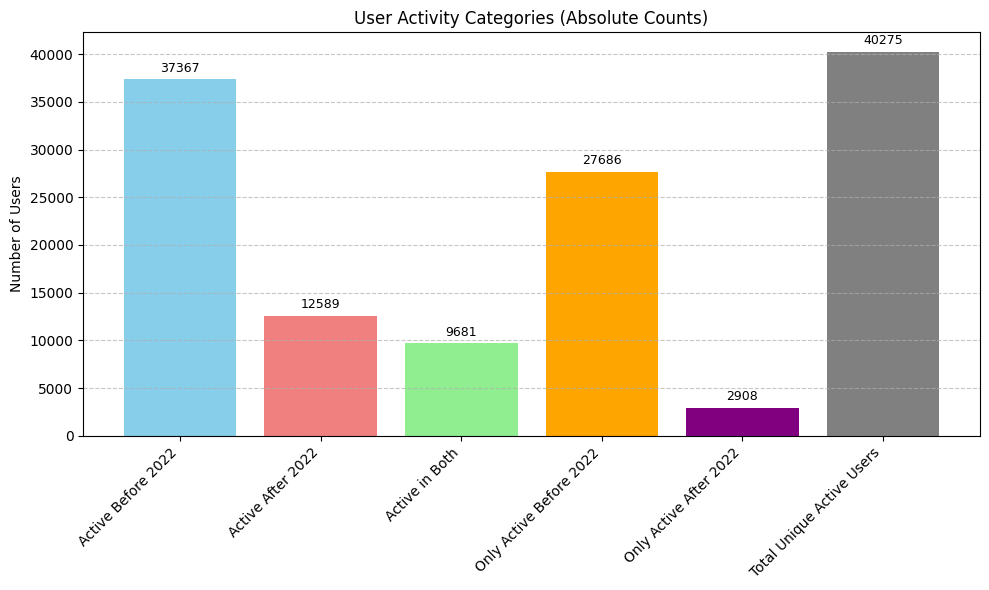

Plot saved to: /mnt/hdd/maittewa/activity_plots/user_activity_proportions.png


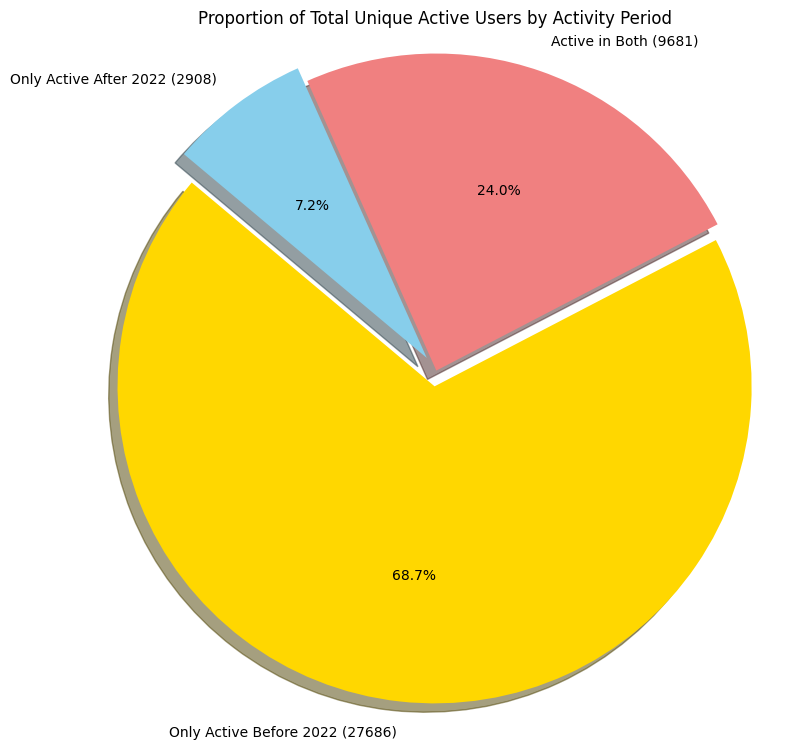

Plot saved to: /mnt/hdd/maittewa/activity_plots/user_retention_rate.png


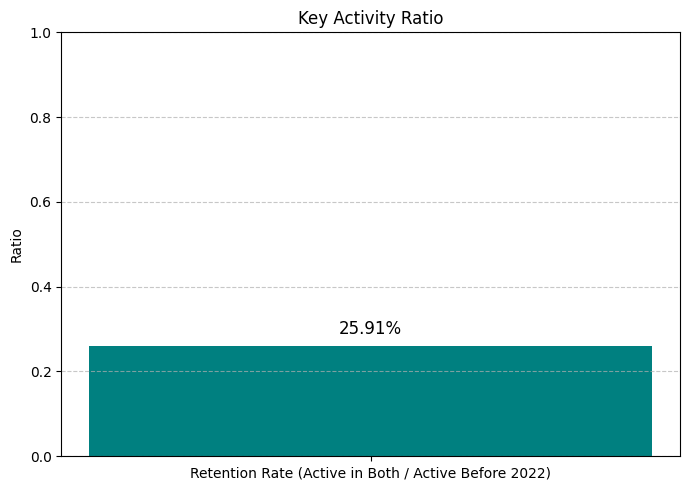


--- Plots Generated and Saved ---


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import os # Import os module to handle file paths

# Provided data
active_before_2022 = 37367
active_after_2022 = 12589
active_in_both = 9681
only_active_before_2022 = 27686
only_active_after_2022 = 2908

print("--- Provided Data ---")
print(f"Active Before 2022: {active_before_2022}")
print(f"Active After 2022: {active_after_2022}")
print(f"Active in Both: {active_in_both}")
print(f"Only Active Before 2022: {only_active_before_2022}")
print(f"Only Active After 2022: {only_active_after_2022}\n")

# --- Derived Totals ---
total_unique_active_users = only_active_before_2022 + active_in_both + only_active_after_2022
print(f"Total Unique Active Users (Overall): {total_unique_active_users}\n")

# --- Define a directory to save plots ---
plots_dir = "/mnt/hdd/maittewa/activity_plots"
os.makedirs(plots_dir, exist_ok=True) # Create directory if it doesn't exist

# --- Plotting ---

# 1. Bar Chart for Absolute Counts
categories = [
    'Active Before 2022',
    'Active After 2022',
    'Active in Both',
    'Only Active Before 2022',
    'Only Active After 2022',
    'Total Unique Active Users'
]
counts = [
    active_before_2022,
    active_after_2022,
    active_in_both,
    only_active_before_2022,
    only_active_after_2022,
    total_unique_active_users
]

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, counts, color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'gray'])
plt.ylabel('Number of Users')
plt.title('User Activity Categories (Absolute Counts)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, round(yval), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# Save the first plot
plot_path_1 = os.path.join(plots_dir, 'user_activity_counts.png')
plt.savefig(plot_path_1, dpi=300) # Save before showing
print(f"Plot saved to: {plot_path_1}")
plt.show() # Display the plot


# 2. Pie Chart for Proportions of Unique Active Users
pie_labels = [
    f'Only Active Before 2022 ({only_active_before_2022})',
    f'Active in Both ({active_in_both})',
    f'Only Active After 2022 ({only_active_after_2022})'
]
pie_sizes = [
    only_active_before_2022,
    active_in_both,
    only_active_after_2022
]
pie_colors = ['gold', 'lightcoral', 'skyblue']
explode = (0.05, 0, 0.05)

plt.figure(figsize=(9, 9))
plt.pie(pie_sizes, explode=explode, labels=pie_labels, colors=pie_colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Proportion of Total Unique Active Users by Activity Period')
plt.axis('equal')

# Save the second plot
plot_path_2 = os.path.join(plots_dir, 'user_activity_proportions.png')
plt.savefig(plot_path_2, dpi=300) # Save before showing
print(f"Plot saved to: {plot_path_2}")
plt.show() # Display the plot


# 3. Optional: Another Bar Chart for specific ratios (e.g., Retention Rate)
if active_before_2022 > 0:
    retention_rate = active_in_both / active_before_2022

    plt.figure(figsize=(7, 5))
    plt.bar(['Retention Rate (Active in Both / Active Before 2022)'], [retention_rate], color='teal')
    plt.ylim(0, 1)
    plt.ylabel('Ratio')
    plt.title('Key Activity Ratio')
    plt.text(0, retention_rate + 0.02, f'{retention_rate:.2%}', ha='center', va='bottom', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    # Save the third plot
    plot_path_3 = os.path.join(plots_dir, 'user_retention_rate.png')
    plt.savefig(plot_path_3, dpi=300) # Save before showing
    print(f"Plot saved to: {plot_path_3}")
    plt.show() # Display the plot

print("\n--- Plots Generated and Saved ---")

In [27]:
meta = pd.read_csv("/mnt/hdd/maittewa/deviantArt_DeviantData/deviantArt_snwBall_fin/deviants_metaDataSnwBall/uniqueDev_metaData_SnwBall_02.csv.gz")

In [28]:
meta.nunique()

Devtn_Id             367005
Devtn_Title          311681
Devtn_Descp          272148
Author_Id              1689
Author_Name            1689
Author_Icon            1647
Author_Type               4
License                   7
Allows_Comments           2
Is_Favourited             1
Is_Mature                 2
Can_post_comments         1
Tags_Info            111851
tag_name             111851
Sponsered                65
Sponser                  65
dtype: int64

In [29]:
meta.head()

,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,Author_Icon,Author_Type,License,Allows_Comments,Is_Favourited,Is_Mature,Can_post_comments,Tags_Info,tag_name,Sponsered,Sponser
0,74D26AE5-C304-60CE-F7BD-E9FEC1B86334,White spring Angel,Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'angel', 'sponsored': False, 'sp...","['angel', 'ceramic', 'sculpture', 'art']","[False, False, False, False]","['', '', '', '']"
1,70E67FA4-3DDD-AE0E-AF61-C4A5D532771D,Little White Severong,Hand made porcelain miniature (5 cm).<br /><br...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,[],[],[],[]
2,56BDA73F-224F-A338-233C-EDA6E4A6254D,Pink-Turquoise Unicorn (Soap Dish - Wall picture),Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'ceramic', 'sponsored': False, '...","['ceramic', 'ceramics', 'clay', 'craft', 'gift...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '']"
3,1A2E67EB-E8C1-1798-886D-D2041B464154,Purple-lavender Fox (Soap Dish - Wall picture),Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'ceramic', 'sponsored': False, '...","['ceramic', 'ceramics', 'clay', 'craft', 'fox'...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '']"
4,8B3C0B89-6E36-1C05-6A8C-BF25167D20E7,Turquoise Jellyfish - Soap Dish - Wall,Hand made and hand glazed ceramic.<br /><br />...,1E5C735B-E687-4EFA-47A3-30D23E077B3E,vavaleff,https://a.deviantart.net/avatars/v/a/vavaleff....,regular,No License,True,False,False,False,"[{'tag_name': 'ceramic', 'sponsored': False, '...","['ceramic', 'ceramics', 'clay', 'craft', 'dish...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '', '..."


In [30]:
# Lambda function to extract only 'ai' or 'AI' tags from the list
meta['ai_extracted_tags_exact'] = meta['tag_name'].apply(
    lambda tags_list: [tag for tag in tags_list if tag in ['ai', 'AI']]
)

In [31]:
meta["used_ai"] = meta["ai_extracted_tags_exact"].apply(
    lambda x: any('AI' in str(tag).upper() for tag in (ast.literal_eval(x) if isinstance(x, str) else []))
)

In [32]:
true_count = meta['used_ai'].sum()

print(f"The number of rows with 'used_ai' as True is: {true_count}")

The number of rows with 'used_ai' as True is: 0


In [25]:
def extract_all_ai_tags(tags_list):
    if not isinstance(tags_list, list):
        return [] # Return empty list if input is not a list
    # Filter for tags containing "AI" (case-insensitive)
    ai_tags_list = [tag for tag in tags_list if isinstance(tag, str) and 'AI' in tag.upper()]
    return ai_tags_list

# Apply the function to the 'tag_name' column (after safely evaluating it)
# This creates a new column 'ai_extracted_tags' containing lists of AI tags found in each row.
meta['ai_extracted_tags'] = meta['tag_name'].apply(
    lambda x: extract_all_ai_tags(ast.literal_eval(x) if isinstance(x, str) else [])
)

In [26]:
# Create a boolean mask for rows where 'used_ai' is True
mask_used_ai = meta['used_ai'] == True

# Create a boolean mask for rows where 'ai_extracted_tags' list is not empty
mask_ai_tags_not_empty = meta['ai_extracted_tags'].apply(lambda x: len(x) > 0)

# Combine the masks to select rows that satisfy both conditions
selected_rows = meta[mask_used_ai & mask_ai_tags_not_empty]

# Display the selected rows (e.g., the first few)
display(selected_rows.head())

,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,Author_Icon,Author_Type,License,Allows_Comments,Is_Favourited,Is_Mature,Can_post_comments,Tags_Info,tag_name,Sponsered,Sponser,used_ai,ai_extracted_tags
542,5C9E62BA-31F0-0B2E-68D3-A5E2DA24C70E,Wuthering Heights,"<p>watercolour, A4</p><p></p><p>You can find i...",89CFD1BC-A6DD-C4C6-7BA4-D7E86CFDF949,JoaRosa,https://a.deviantart.net/avatars/j/o/joarosa.j...,regular,No License,True,False,False,False,"[{'tag_name': 'watercolour', 'sponsored': Fals...","['watercolour', 'traditionalart', 'landscapepa...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '']",True,[landscapepainting]
546,7AC999B0-C885-64E9-3CEC-0822D1AAF5FF,The twin ponds view,"<p>watercolour, A4</p><p>You can find it in my...",89CFD1BC-A6DD-C4C6-7BA4-D7E86CFDF949,JoaRosa,https://a.deviantart.net/avatars/j/o/joarosa.j...,regular,No License,True,False,False,False,"[{'tag_name': 'plants', 'sponsored': False, 's...","['plants', 'watercolour', 'traditionalart', 'r...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '']",True,[landscapepainting]
548,6E20E7B3-754B-9D57-5639-0A9AD7AA9752,Cherries,"<p>watercolour, A4</p><p></p><p>Based on <a ta...",89CFD1BC-A6DD-C4C6-7BA4-D7E86CFDF949,JoaRosa,https://a.deviantart.net/avatars/j/o/joarosa.j...,regular,Creative Commons Attribution-Noncommercial-No ...,True,False,False,False,"[{'tag_name': 'plants', 'sponsored': False, 's...","['plants', 'traditionalart', 'watercolour', 'c...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '']",True,[painting]
549,B67AC74D-E7FC-69EB-C9F2-F99FB532B2BF,Abstract,<p>watercolour</p><p></p><p>You can buy it in ...,89CFD1BC-A6DD-C4C6-7BA4-D7E86CFDF949,JoaRosa,https://a.deviantart.net/avatars/j/o/joarosa.j...,regular,Creative Commons Attribution-Noncommercial-No ...,True,False,False,False,"[{'tag_name': 'watercolour', 'sponsored': Fals...","['watercolour', 'traditionalart', 'rainbow', '...","[False, False, False, False, False, False]","['', '', '', '', '', '']",True,[rainbow]
551,60A6345E-2A01-FE99-5BCE-68C68F2195E7,Lemons,"<p>watercolour, A4</p><p></p><p>comissioned wo...",89CFD1BC-A6DD-C4C6-7BA4-D7E86CFDF949,JoaRosa,https://a.deviantart.net/avatars/j/o/joarosa.j...,regular,No License,True,False,False,False,"[{'tag_name': 'watercolour', 'sponsored': Fals...","['watercolour', 'traditionalart', 'fruits', 'l...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '']",True,[painting]


In [24]:
pat1 = r"<br\s*/?>"
pat2 = r"<[^>]+>"
pat3 = r"[^a-zA-Z0-9 ]"
meta["Clean Description"] = meta["Devtn_Descp"].astype(str).str.replace(pat1, "\n", regex=True)
meta["Clean Description"] = meta["Devtn_Descp"].str.replace(pat2, " ", regex=True)
meta["Clean Description"] = meta["Devtn_Descp"].str.replace(pat3, " ", regex=True)


In [26]:
meta["Clean Description"].tail()

322122     a href  https   donotuseplz deviantart com   ...
322123    This is one of three artworks i did  or rather...
322124     a href  https   sallyfoxlover deviantart com ...
322125     img src  https   e deviantart net emoticons s...
322126    I drew this over a period of serveral ICT clas...
Name: Clean Description, dtype: object

In [32]:
import pandas as pd
import numpy as np # Import numpy if not already there, good practice for NaN


# Original pattern: just captures the trigger phrase
# New pattern: captures the ENTIRE line starting with the trigger phrase
# The outer () makes sure the *whole match* is captured in the resulting Series
pattern_full_match = r"((?:created by|created using|i created it|i used to create) .*) "

# Apply the regex extraction directly to the new column
# .fillna('') is good practice to convert NaNs to empty strings before .str accessor
# .str.extract(pattern, expand=False) will give a Series where values are the matched string
# or NaN if no match.
meta["Created_using"] = meta['Devtn_Descp'].fillna('').str.extract(pattern_full_match, expand=False)

# Optional: Further clean 'Created_using' to remove leading/trailing spaces
meta["Created_using"] = meta["Created_using"].str.strip()


print(meta)

                                    Devtn_Id  \
0       74D26AE5-C304-60CE-F7BD-E9FEC1B86334   
1       70E67FA4-3DDD-AE0E-AF61-C4A5D532771D   
2       56BDA73F-224F-A338-233C-EDA6E4A6254D   
3       1A2E67EB-E8C1-1798-886D-D2041B464154   
4       8B3C0B89-6E36-1C05-6A8C-BF25167D20E7   
...                                      ...   
322122  D2EAC2ED-9079-EDDA-F448-384D0738385A   
322123  E78CD85E-906F-A0D5-9B9E-EE8AFE9FF2F8   
322124  47B89A5C-AD38-188A-1B2C-EEF99F2DA530   
322125  33F46394-AE2E-3077-6BBF-1587384F0D72   
322126  8D9379F9-6CF5-EE6F-B20D-83569DC6257C   

                                              Devtn_Title  \
0                                      White spring Angel   
1                                   Little White Severong   
2       Pink-Turquoise Unicorn (Soap Dish - Wall picture)   
3          Purple-lavender Fox (Soap Dish - Wall picture)   
4                 Turquoise Jellyfish  - Soap Dish - Wall   
...                                                   ...

In [35]:
meta.Created_using.value_counts()

Created_using
created using the Gimp graphics program based on an AI                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

In [28]:
matching_rows

,Devtn_Id,Devtn_Title,Devtn_Descp,Author_Id,Author_Name,Author_Icon,Author_Type,License,Allows_Comments,Is_Favourited,Is_Mature,Can_post_comments,Tags_Info,tag_name,Sponsered,Sponser,Clean Description
5625,DC3B940B-534D-D678-72F8-B78E97938ACA,Crowley for ecopharmgeek,"<span>Crowley is about 12"" tall. Materials use...",81D244EA-86CD-B3B7-B751-6CA576FC6723,MasterPlanner,https://a.deviantart.net/avatars/m/a/masterpla...,regular,No License,True,False,False,False,"[{'tag_name': 'crochet', 'sponsored': False, '...","['crochet', 'crowley', 'cute', 'demon', 'goodo...","[False, False, False, False, False, False]","['', '', '', '', '', '']",span Crowley is about 12 tall Materials use...
5633,8606EA8F-17C8-C7B7-E390-D0F7F7639C74,The Moon Man,"<i>""Is it a sad song?""<br />""</i><i>Nothing&#8...",81D244EA-86CD-B3B7-B751-6CA576FC6723,MasterPlanner,https://a.deviantart.net/avatars/m/a/masterpla...,regular,No License,True,False,False,False,"[{'tag_name': '12thdoctor', 'sponsored': False...","['12thdoctor', 'petercapaldi', 'twelfthdoctor'...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '', '']",i Is it a sad song br i i Nothing 8...
5634,44206BAB-8AC2-7AE0-A62E-ED32EAA730BF,trash gryphon,"the trash gryphon is about 4"" long not includi...",81D244EA-86CD-B3B7-B751-6CA576FC6723,MasterPlanner,https://a.deviantart.net/avatars/m/a/masterpla...,regular,No License,True,False,False,False,"[{'tag_name': 'pigeon', 'sponsored': False, 's...","['pigeon', 'rat', 'amigurumi', 'crochet', 'cut...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '']",the trash gryphon is about 4 long not includi...
5636,451EC27A-F9A5-6594-68DC-1A61C31D0845,the masked gentleman for inky-shade,"Stands about 6"" tall not including hat. Materi...",81D244EA-86CD-B3B7-B751-6CA576FC6723,MasterPlanner,https://a.deviantart.net/avatars/m/a/masterpla...,regular,No License,True,False,False,False,"[{'tag_name': 'chibi', 'sponsored': False, 'sp...","['chibi', 'crochet', 'plush', 'amigurumi', 'pr...","[False, False, False, False, False]","['', '', '', '', '']",Stands about 6 tall not including hat Materi...
5644,2A869C23-527C-8A7F-E7D6-C7C0F9218D42,Paletta Acrylica for Pektorel,"<span>Paletta stands at about 12"" tall, not in...",81D244EA-86CD-B3B7-B751-6CA576FC6723,MasterPlanner,https://a.deviantart.net/avatars/m/a/masterpla...,regular,No License,True,False,False,False,"[{'tag_name': 'crochet', 'sponsored': False, '...","['crochet', 'kawaii', 'mylittlepony', 'pegasus...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '', '']",span Paletta stands at about 12 tall not in...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
320620,2CCA03A3-979C-7591-4AD2-C60C2B7CE434,Garfield the Deals Warlock,"Continuing my Adventure Zone art shenanigans, ...",F605DE59-D9CD-C653-C6B2-8F9213A4DCF8,Turtle-Arts,https://a.deviantart.net/avatars/t/u/turtle-ar...,regular,No License,True,False,False,False,"[{'tag_name': 'taz', 'sponsored': False, 'spon...","['taz', 'garfieldthedealswarlock', 'fantasycos...","[False, False, False, False, False, False, Fal...","['', '', '', '', '', '', '', '', '']",Continuing my Adventure Zone art shenanigans ...
320657,1FEC9012-0782-09A9-2B9D-9C9E017D5739,Sybal Heim,&nbsp; &nbsp;&nbsp;Sybal Heim is a moderately ...,F605DE59-D9CD-C653-C6B2-8F9213A4DCF8,Turtle-Arts,https://a.deviantart.net/avatars/t/u/turtle-ar...,regular,No License,True,False,False,False,"[{'tag_name': 'map', 'sponsored': False, 'spon...","['map', 'sybalheim']","[False, False]","['', '']",nbsp nbsp nbsp Sybal Heim is a moderately ...
320741,DB1D4340-F9FC-C97C-B8B9-1346FEB636B2,In the beginning there was the sky,Heeeeeeeeey Yooooouuuuuuuu guuuuuuuuyyyyysssss...,F605DE59-D9CD-C653-C6B2-8F9213A4DCF8,Turtle-Arts,https://a.deviantart.net/avatars/t/u/turtle-ar...,regular,No License,True,False,False,False,[],[],[],[],Heeeeeeeeey Yooooouuuuuuuu guuuuuuuuyyyyysssss...
322122,D2EAC2E